## part 3: analysis/ figures from random sampled TC data

In [1]:
!pip uninstall dea-tools -y

In [2]:
%pip install ultraplot xskillscore -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import datacube
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import ultraplot as uplt
import xskillscore
import cartopy.crs as ccrs
from matplotlib.dates import MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from datacube.utils import masking
from scipy.stats import linregress
import calendar
import warnings
import time
import odc.geo.xr
from odc.geo.geom import Geometry, CRS
from shapely.geometry import box

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression



from odc.algo._percentile import xr_quantile_bands

import sys

sys.path.insert(1, "../../../Tools")
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import calculate_indices
from dea_tools.spatial import add_geobox

warnings.filterwarnings("ignore")


### This version of the notebook reads in the csv files from random sampled poitns across AU



In [4]:

def rmse(x, y):
    return np.sqrt(np.mean((x - y) ** 2))

def mae(x, y):
    return np.mean(np.abs(x-y))

def bias(x, y):
    return np.mean(x-y)


In [5]:
csv_files = glob.glob('temp_outputs/*.csv')

colnames = ['class', 'TCW', 'TCB', 'TCG', 'TCW_DEA', 'TCB_DEA', 'TCG_DEA', 'TCW_ls8', 'TCB_ls8', 'TCG_ls8']

dfs = []

for file in csv_files:
    parts = file.split('_')
    classname = parts[3]
    #print(classname)
    
    df = pd.read_csv(file, usecols=colnames)
    df['classname'] = classname

    dfs.append(df)

    
#dfs = [pd.read_csv(file, sep=' ', usecols=colnames) for file in csv_files]

combined_df = pd.concat(dfs, ignore_index=True)

In [6]:
combined_df

,class,TCW,TCG,TCB,TCW_DEA,TCB_DEA,TCG_DEA,TCW_ls8,TCB_ls8,TCG_ls8,classname
0,40.0,-0.343292,0.015310,0.334093,-0.186755,0.528521,-0.054765,-0.250793,0.518441,0.007040,cropland
1,40.0,-0.335815,0.055465,0.339959,-0.209164,0.530078,-0.029725,-0.239276,0.521131,0.046413,cropland
2,40.0,-0.303964,0.039052,0.332728,-0.170835,0.498799,-0.017462,-0.220038,0.492230,0.032349,cropland
3,40.0,-0.310137,0.052373,0.420295,-0.178643,0.591218,-0.002329,-0.211767,0.586026,0.041634,cropland
4,40.0,-0.342098,0.018366,0.329182,-0.206729,0.518070,-0.063427,-0.251150,0.513022,0.011868,cropland
...,...,...,...,...,...,...,...,...,...,...,...
3423,10.0,-0.175783,0.098484,0.245872,-0.130520,0.342281,0.050894,-0.113474,0.338817,0.091035,tree
3424,10.0,-0.212086,0.050497,0.253970,-0.138375,0.375600,-0.004636,-0.143110,0.370891,0.041860,tree
3425,10.0,-0.147096,0.106578,0.212736,-0.124534,0.292592,0.057866,-0.091977,0.290611,0.099988,tree
3426,10.0,-0.130936,0.099263,0.206566,-0.107051,0.277987,0.060440,-0.079542,0.275880,0.092394,tree


In [7]:
variable_pairs = {
    "baig_l8": [("TCW", "TCW_ls8"), ("TCG", "TCG_ls8"), ("TCB", "TCB_ls8")],
    "DEA_l8": [("TCW", "TCW_DEA"), ("TCG", "TCG_DEA"), ("TCB", "TCB_DEA")],
}

worldview_class_list = list(combined_df['classname'].unique())

In [8]:
#Calculate RMSE, MAI and bias for each pixel/ timestep
rmse_results = []
mae_results = []
bias_results = []

for i, group in variable_pairs.items():
    print(group)
    for j, (var1, var2) in enumerate(group):
        diff_name = f'diff_{var2}'
        combined_df[diff_name] = combined_df[var1] - combined_df[var2]

        for cls, group in combined_df.groupby('classname'):
            cls_name = f'{var2}_{cls}'
            rmse_error = rmse(group[var1], group[var2])
            mae_error = mae(group[var1], group[var2])
            bias_error = bias(group[var1], group[var2])
            
            rmse_results.append({'class': cls_name, 'RMSE': rmse_error})
            mae_results.append({'class': cls_name, 'MAE': mae_error})
            bias_results.append({'class': cls_name, 'BIAS': bias_error})

rmse_df = pd.DataFrame(rmse_results)
mae_df = pd.DataFrame(mae_results)
bias_df = pd.DataFrame(bias_results)


[('TCW', 'TCW_ls8'), ('TCG', 'TCG_ls8'), ('TCB', 'TCB_ls8')]
[('TCW', 'TCW_DEA'), ('TCG', 'TCG_DEA'), ('TCB', 'TCB_DEA')]


In [9]:
merged_df = pd.merge(rmse_df, mae_df, on='class')
merged_df = pd.merge(merged_df, bias_df, on='class')

In [10]:
merged_df.head()

,class,RMSE,MAE,BIAS
0,TCW_ls8_bare,0.113000,0.108429,-0.108429
1,TCW_ls8_built-up,0.076093,0.074825,-0.074825
2,TCW_ls8_cropland,0.087272,0.085837,-0.085837
3,TCW_ls8_grassland,0.095555,0.093133,-0.093133
4,TCW_ls8_mangroves,0.049975,0.049175,-0.049175


In [11]:
combined_df.head()

,class,TCW,TCG,TCB,TCW_DEA,TCB_DEA,TCG_DEA,TCW_ls8,TCB_ls8,TCG_ls8,classname,diff_TCW_ls8,diff_TCG_ls8,diff_TCB_ls8,diff_TCW_DEA,diff_TCG_DEA,diff_TCB_DEA
0,40.0,-0.343292,0.015310,0.334093,-0.186755,0.528521,-0.054765,-0.250793,0.518441,0.007040,cropland,-0.092499,0.008270,-0.184348,-0.156537,0.070075,-0.194428
1,40.0,-0.335815,0.055465,0.339959,-0.209164,0.530078,-0.029725,-0.239276,0.521131,0.046413,cropland,-0.096539,0.009052,-0.181172,-0.126651,0.085190,-0.190119
2,40.0,-0.303964,0.039052,0.332728,-0.170835,0.498799,-0.017462,-0.220038,0.492230,0.032349,cropland,-0.083926,0.006703,-0.159502,-0.133129,0.056514,-0.166071
3,40.0,-0.310137,0.052373,0.420295,-0.178643,0.591218,-0.002329,-0.211767,0.586026,0.041634,cropland,-0.098370,0.010739,-0.165731,-0.131494,0.054702,-0.170923
4,40.0,-0.342098,0.018366,0.329182,-0.206729,0.518070,-0.063427,-0.251150,0.513022,0.011868,cropland,-0.090948,0.006498,-0.183840,-0.135369,0.081793,-0.188888


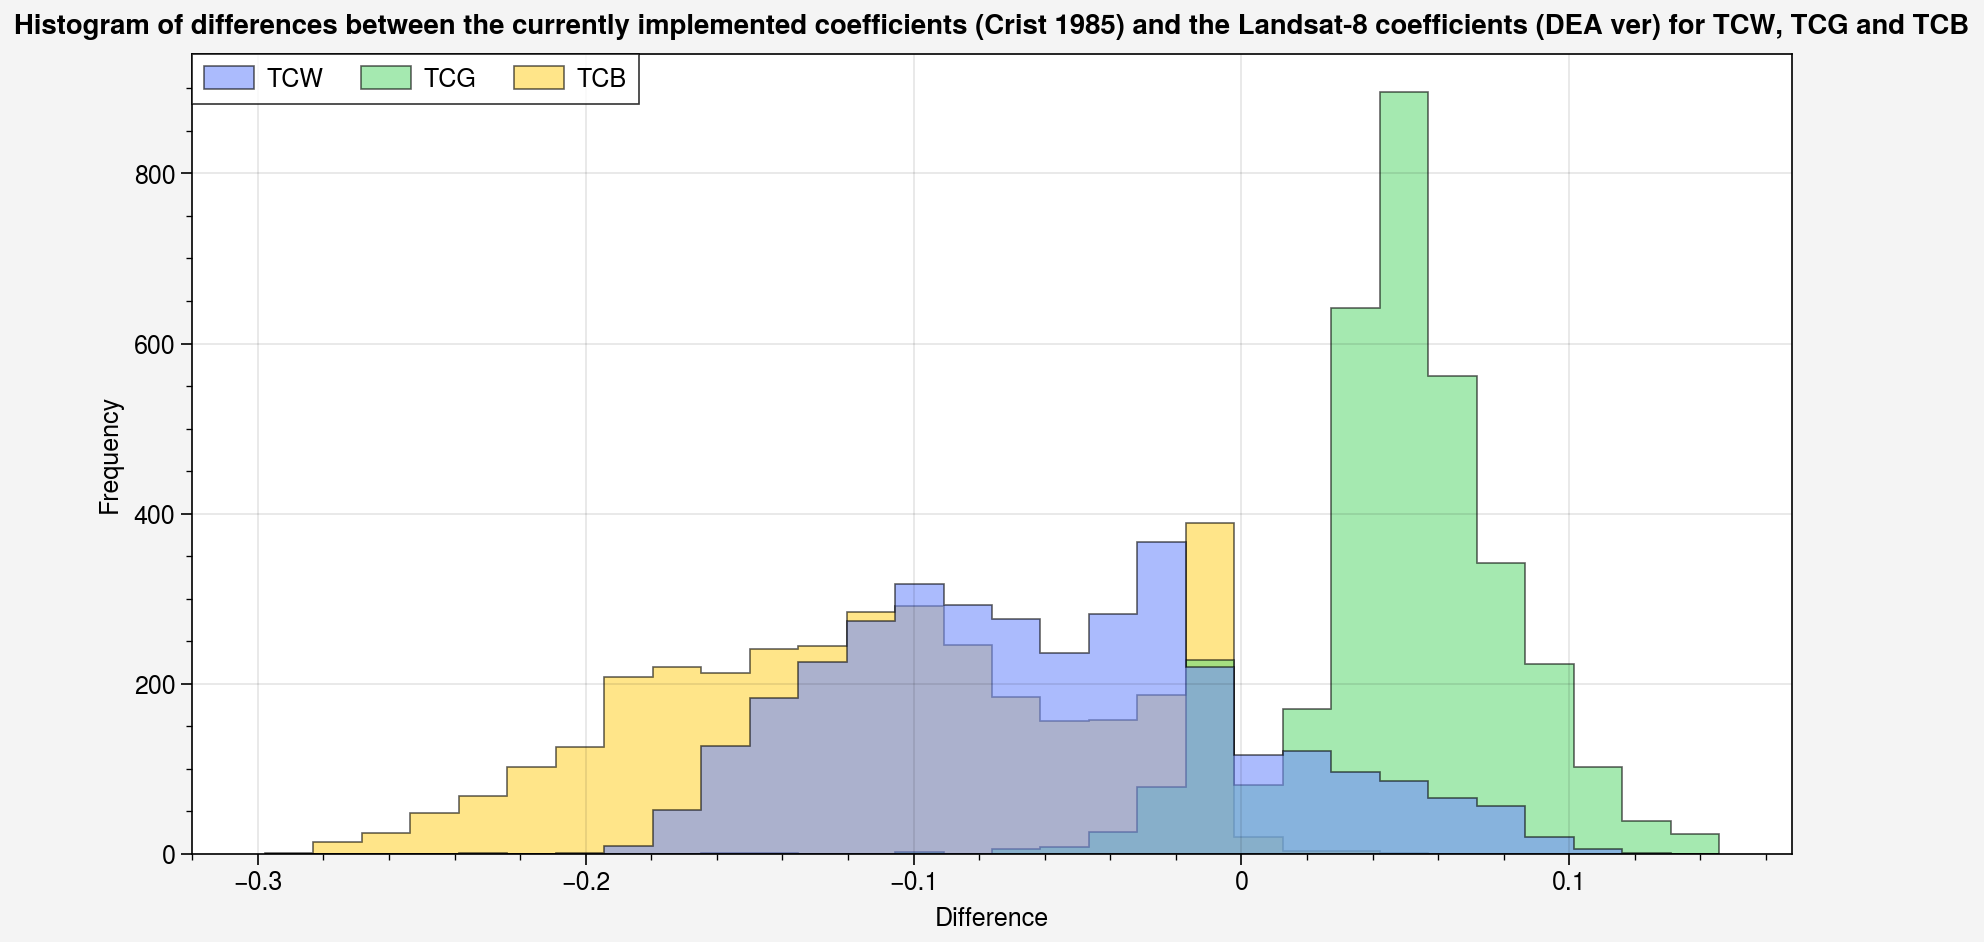

In [12]:
hist_test_dea = combined_df[['diff_TCW_DEA', 'diff_TCG_DEA', 'diff_TCB_DEA']]

fig, ax = uplt.subplots(refwidth=8, refaspect=(8,4))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the Landsat-8 coefficients (DEA ver) for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    hist_test_dea,
    bins=30,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)


fig.savefig("histogram_tc_diff_dea.png", dpi=100, bbox_inches='tight')
#plt.close()

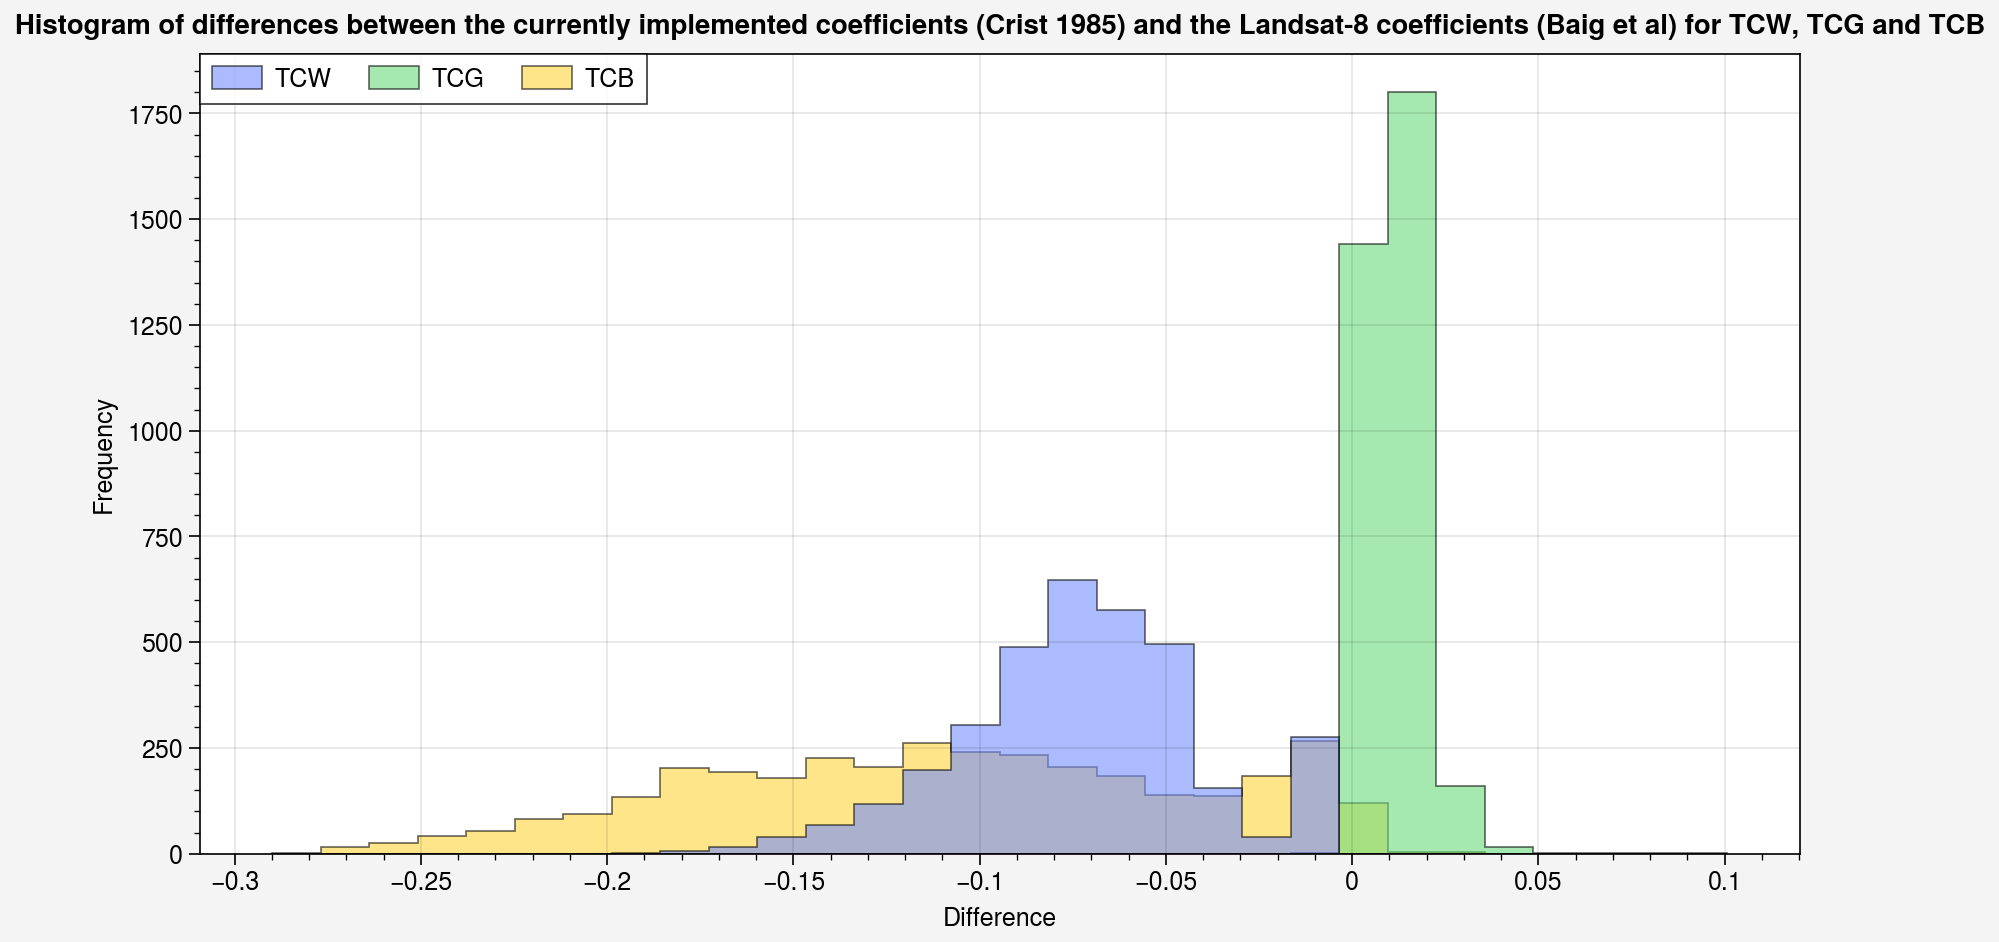

In [13]:
hist_test_baig = combined_df[['diff_TCW_ls8', 'diff_TCG_ls8', 'diff_TCB_ls8']]

fig, ax = uplt.subplots(refwidth=8, refaspect=(8,4))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the Landsat-8 coefficients (Baig et al) for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    hist_test_baig,
    bins=30,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)

fig.savefig("histogram_tc_diff_baig.png", dpi=100, bbox_inches='tight')
#plt.close()

In [14]:
wetland_mangroves_water_df = combined_df[combined_df['classname'].isin(['water', 'mangroves', 'wetland'])]

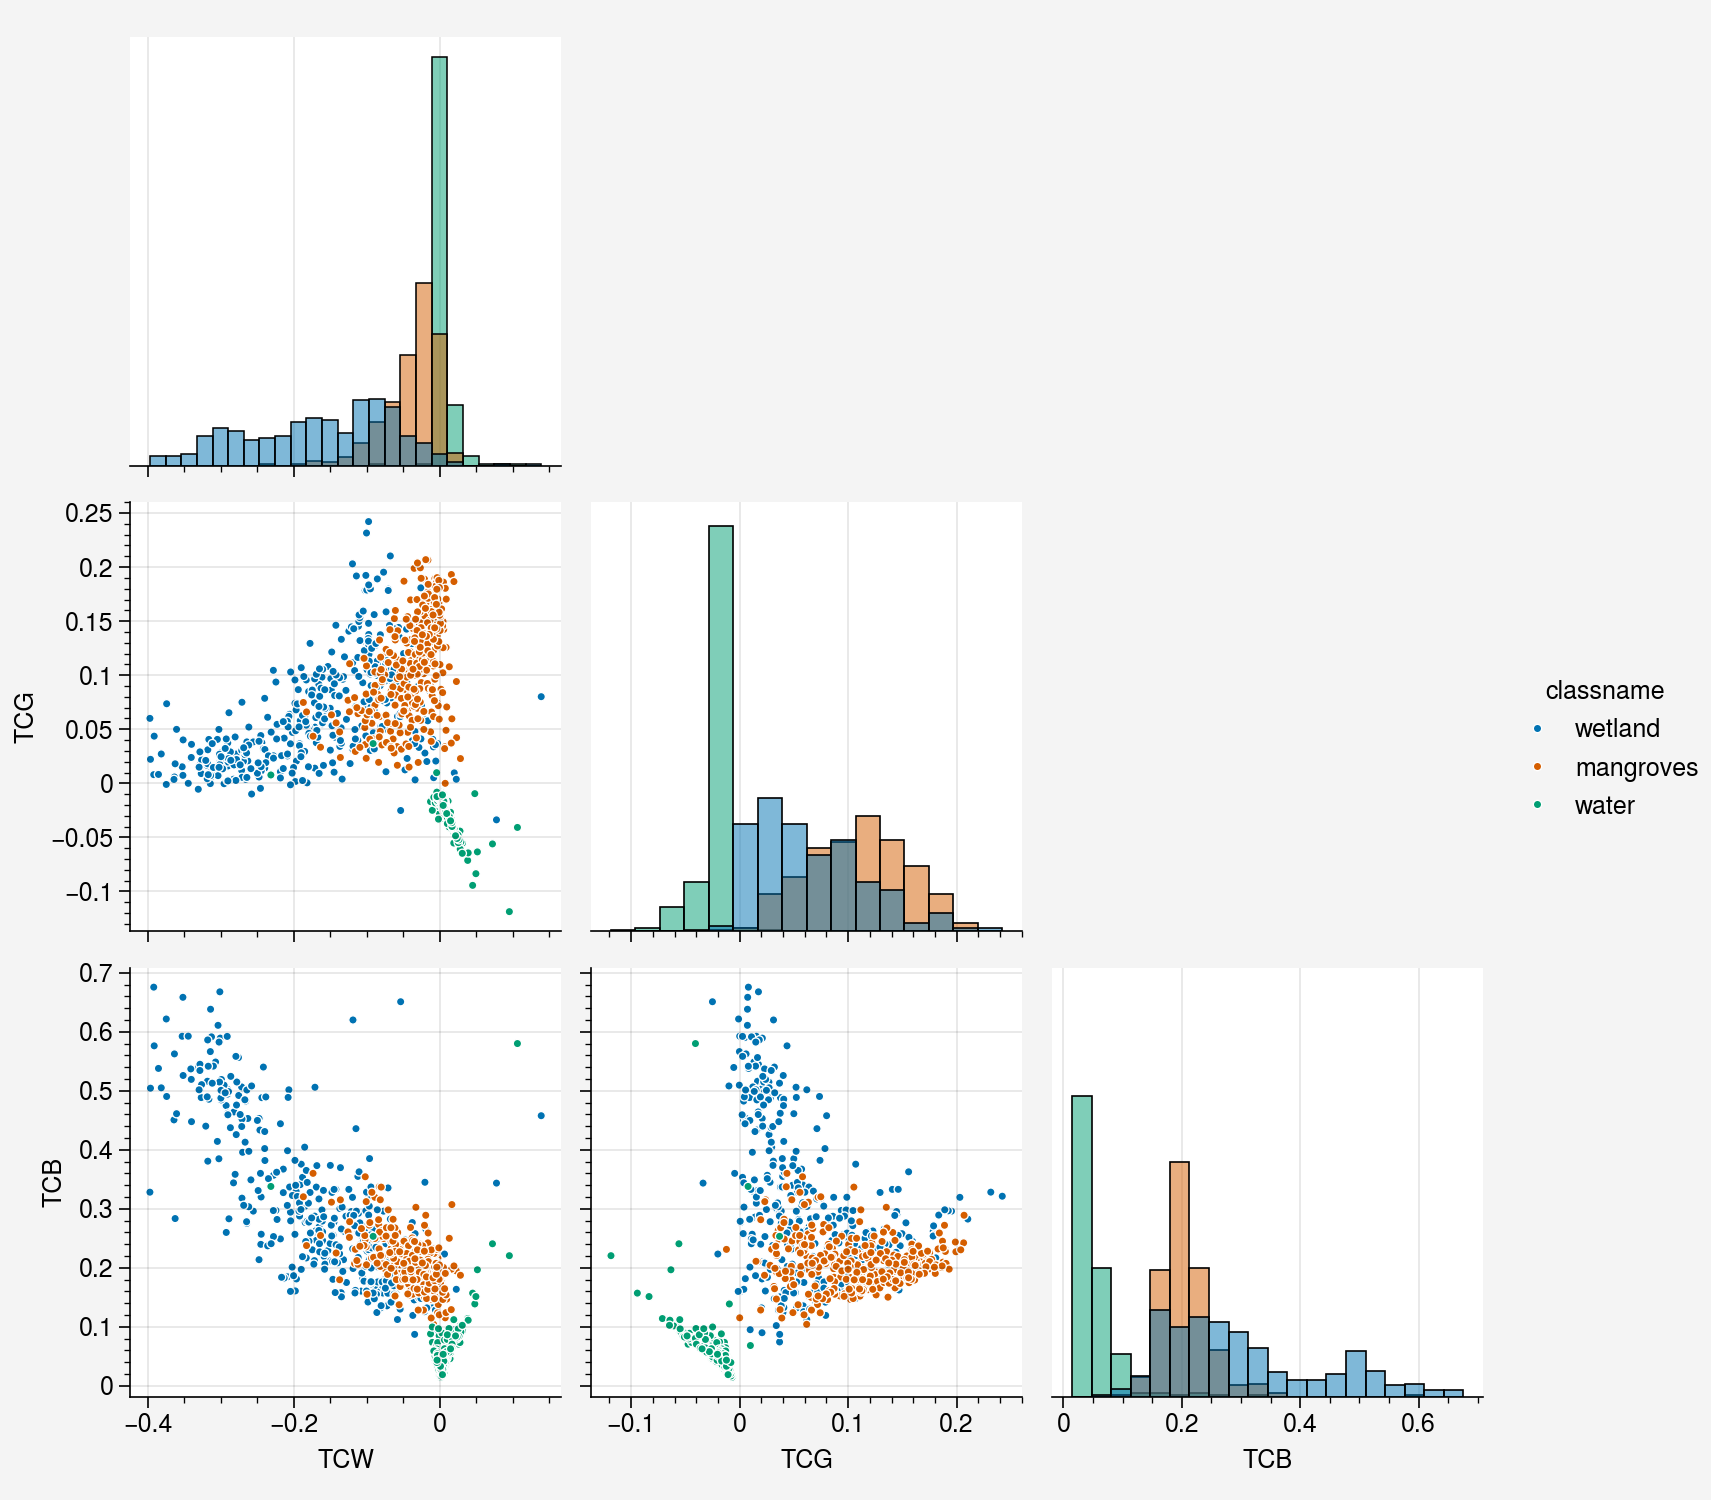

In [15]:

# g = sns.PairGrid(wetland_mangroves_water_df, vars=['TCW', 'TCG', 'TCB'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_current_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()

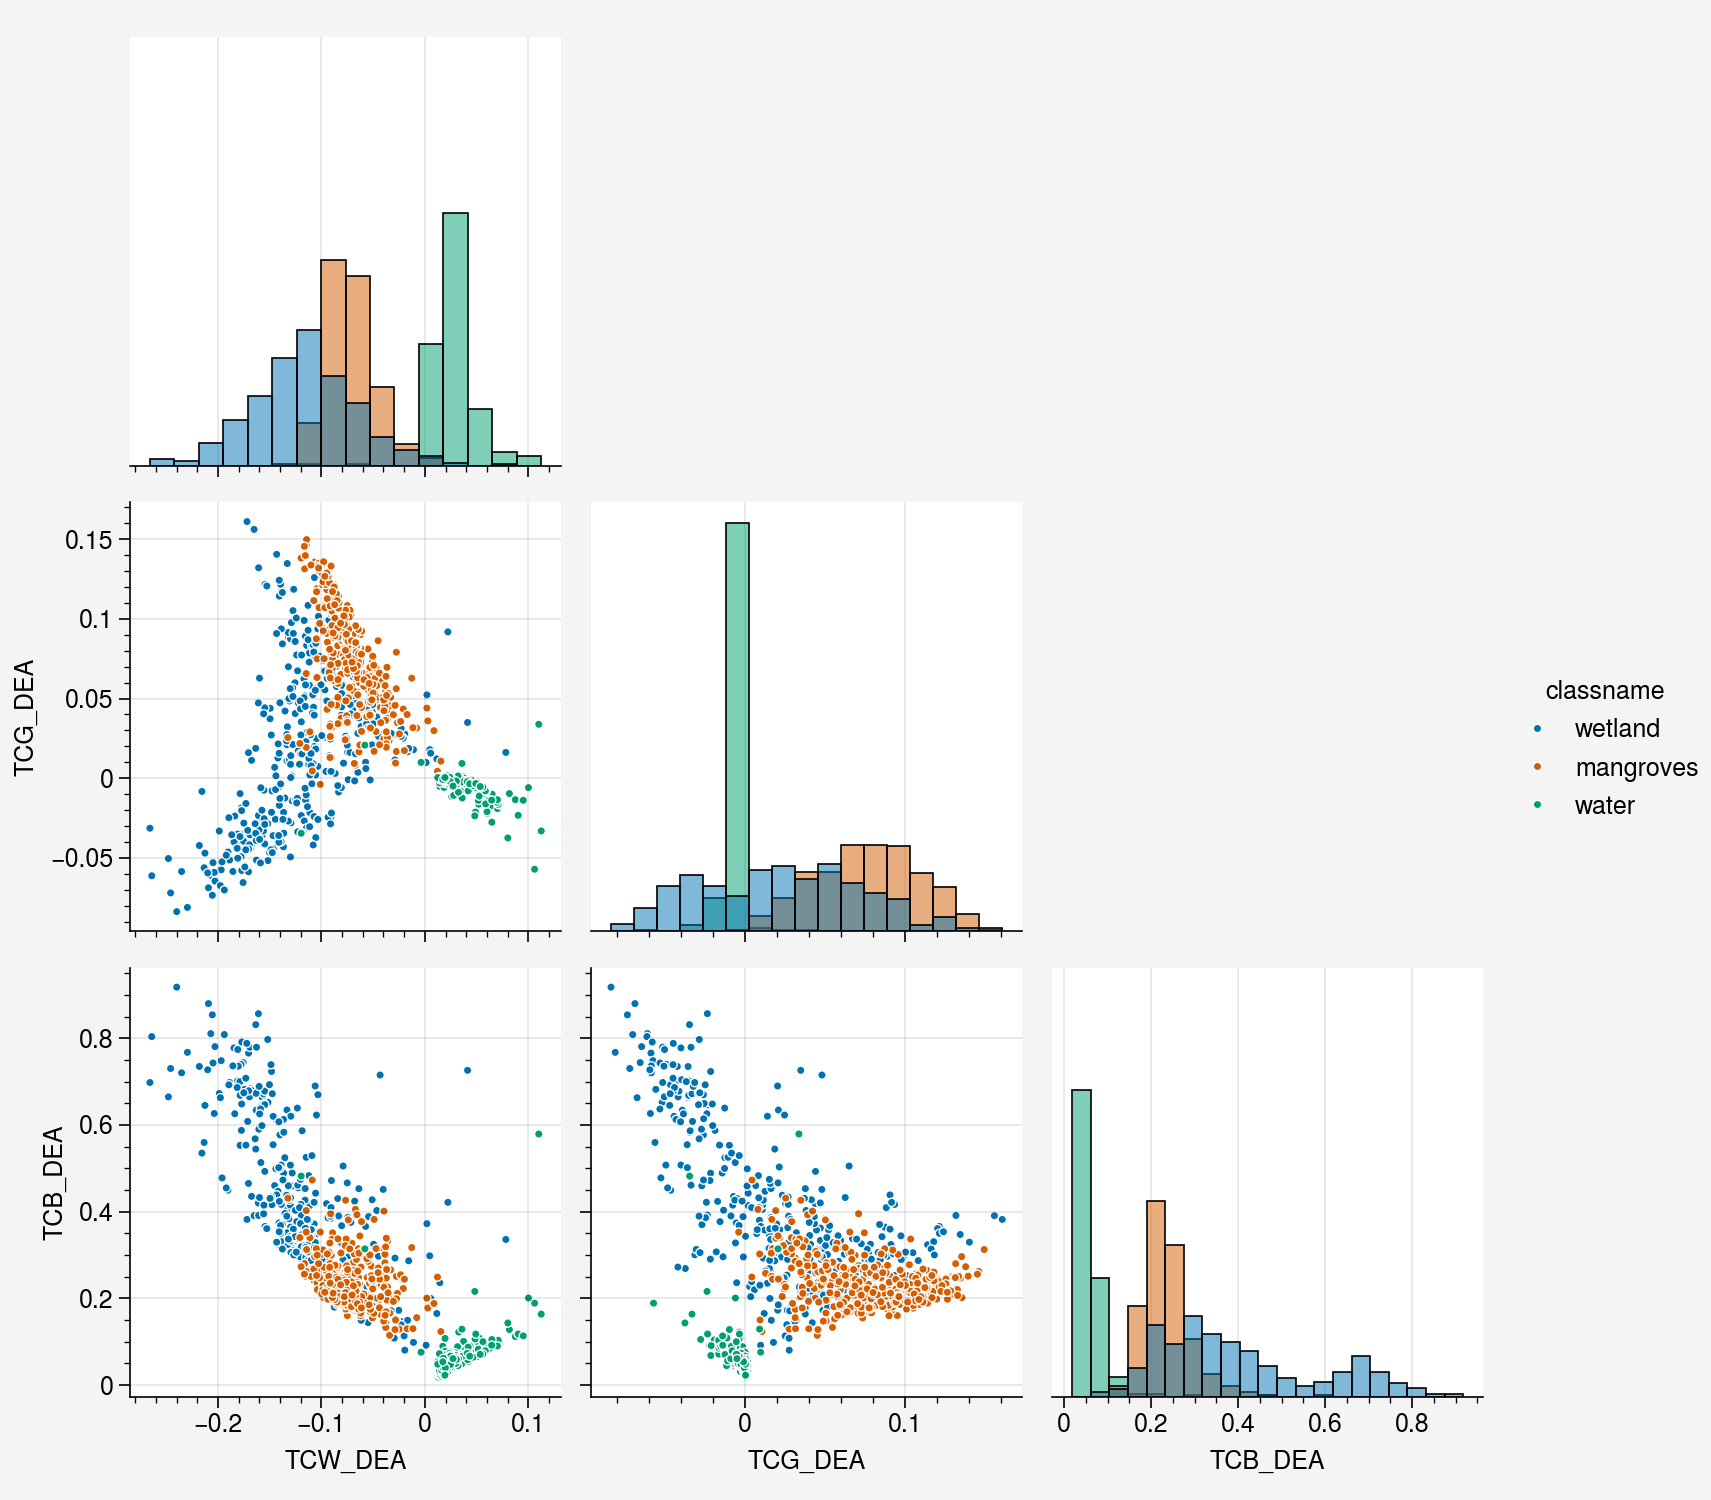

In [16]:
# g = sns.PairGrid(wetland_mangroves_water_df, vars=['TCW_DEA', 'TCG_DEA', 'TCB_DEA'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_dea_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()

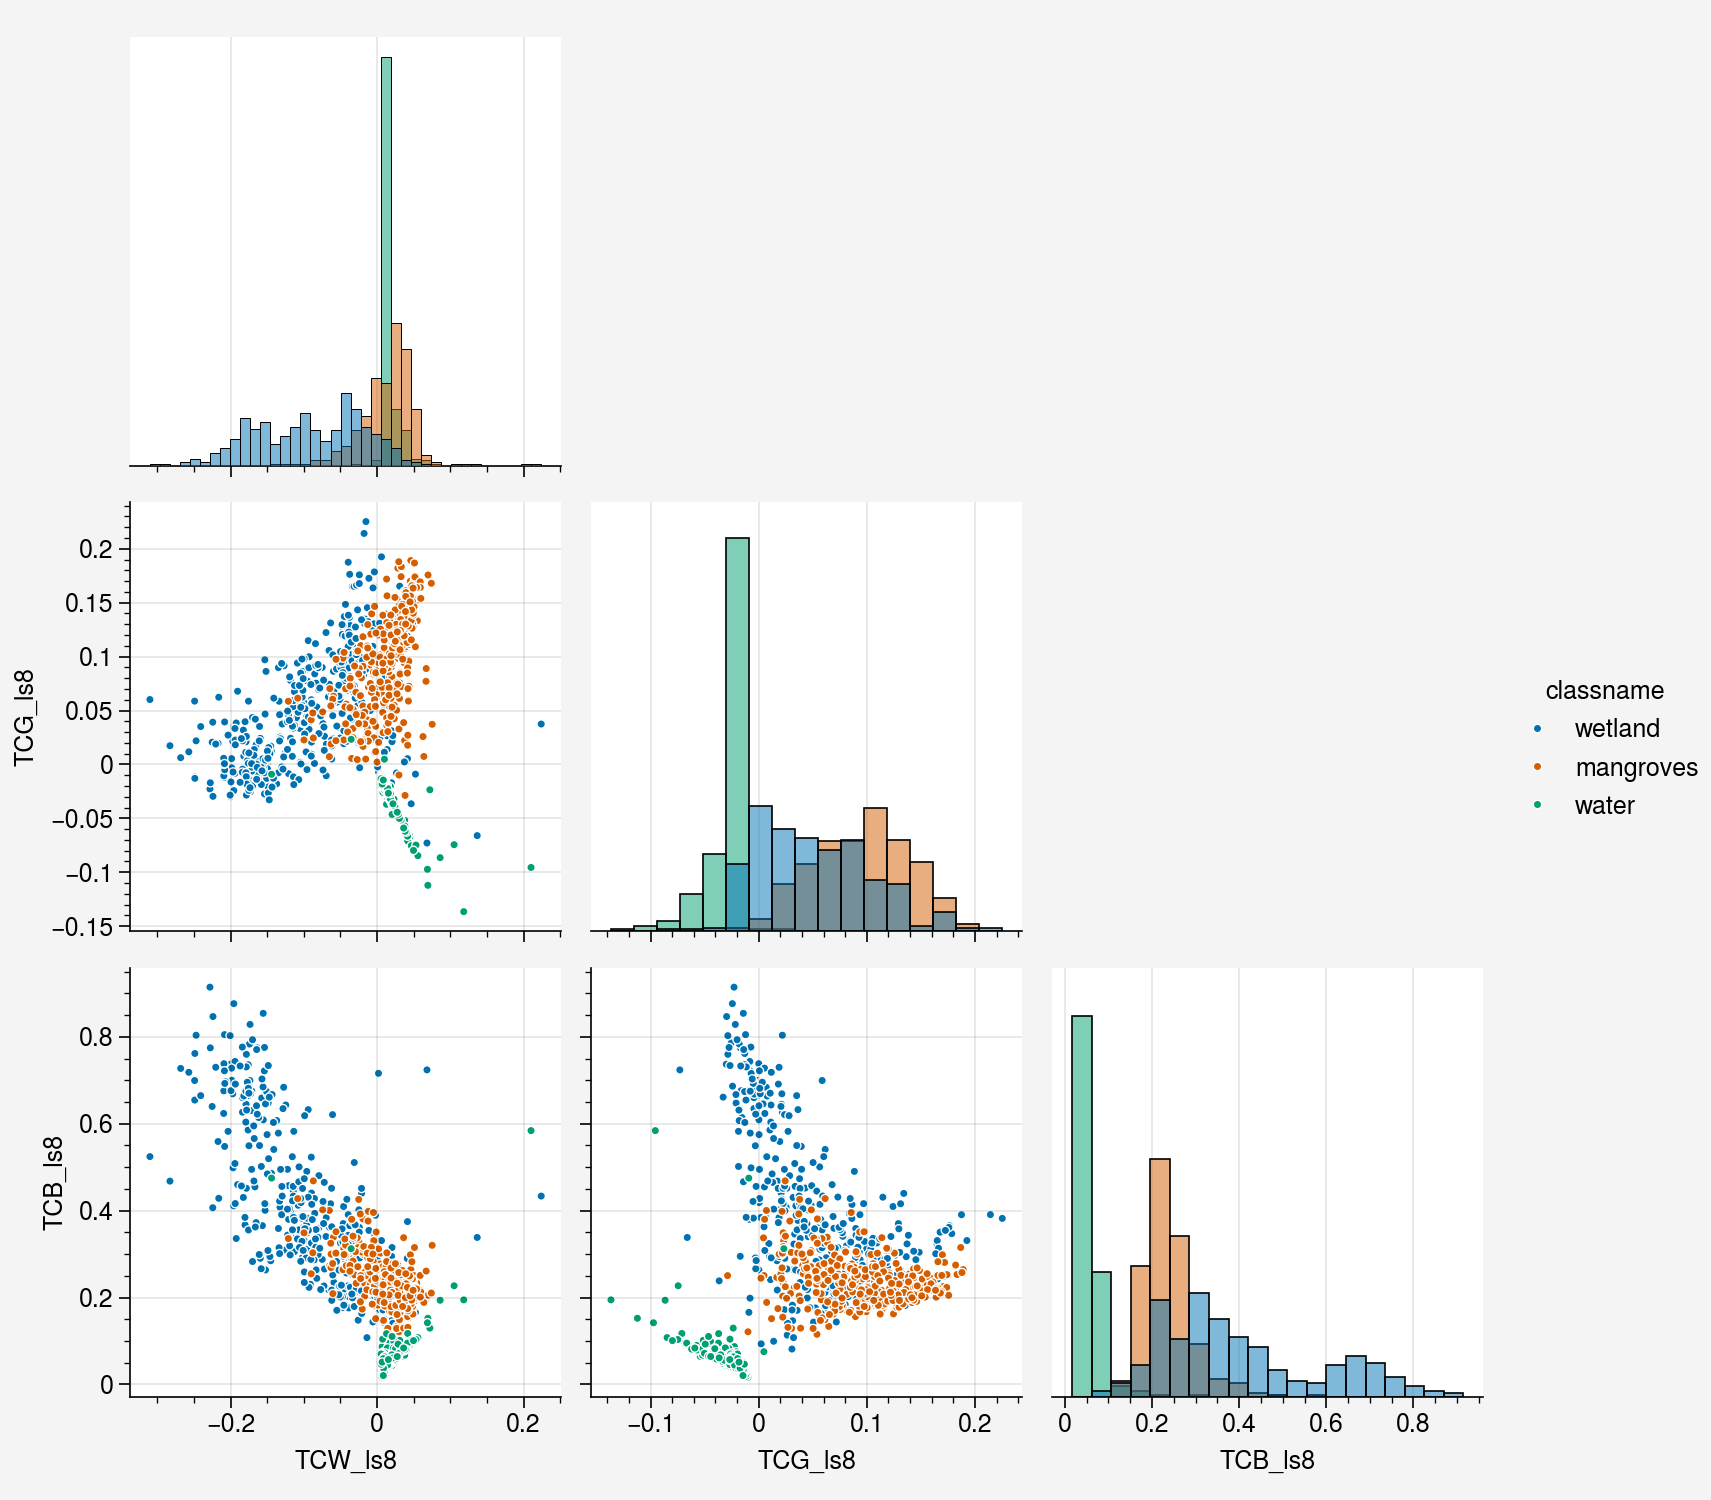

In [17]:
# g = sns.PairGrid(wetland_mangroves_water_df, vars=['TCW_ls8', 'TCG_ls8', 'TCB_ls8'], hue='classname', corner=True)
# g.map_diag(sns.histplot,  color='0.3') #multiple='stack', element='step',
# g.map_offdiag(sns.scatterplot, marker='.')
# g.add_legend()

# g.savefig("pairgrid_tc_baig_coefs.png", dpi=100, bbox_inches='tight')
# #plt.close()

In [18]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

combined_no_water_df = combined_df[~combined_df['classname'].isin(['water'])]

classes = list(combined_no_water_df['classname'].unique())
bandwidth = 1

darkgreen = '#9BC184'
midgreen = '#C2D6A4'
lightgreen = '#E7E5CB'
colors = [lightgreen, midgreen, darkgreen, midgreen, lightgreen]

darkgrey = '#525252'

In [19]:
def add_arrow(head_pos, tail_pos, ax):
    style = "Simple, tail_width=0.01, head_width=1, head_length=2"
    kw = dict(arrowstyle=style, color="k", linewidth=0.2)
    arrow = patches.FancyArrowPatch(
        tail_pos, head_pos,
        connectionstyle="arc3,rad=.5",
        **kw
    )
    ax.add_patch(arrow)

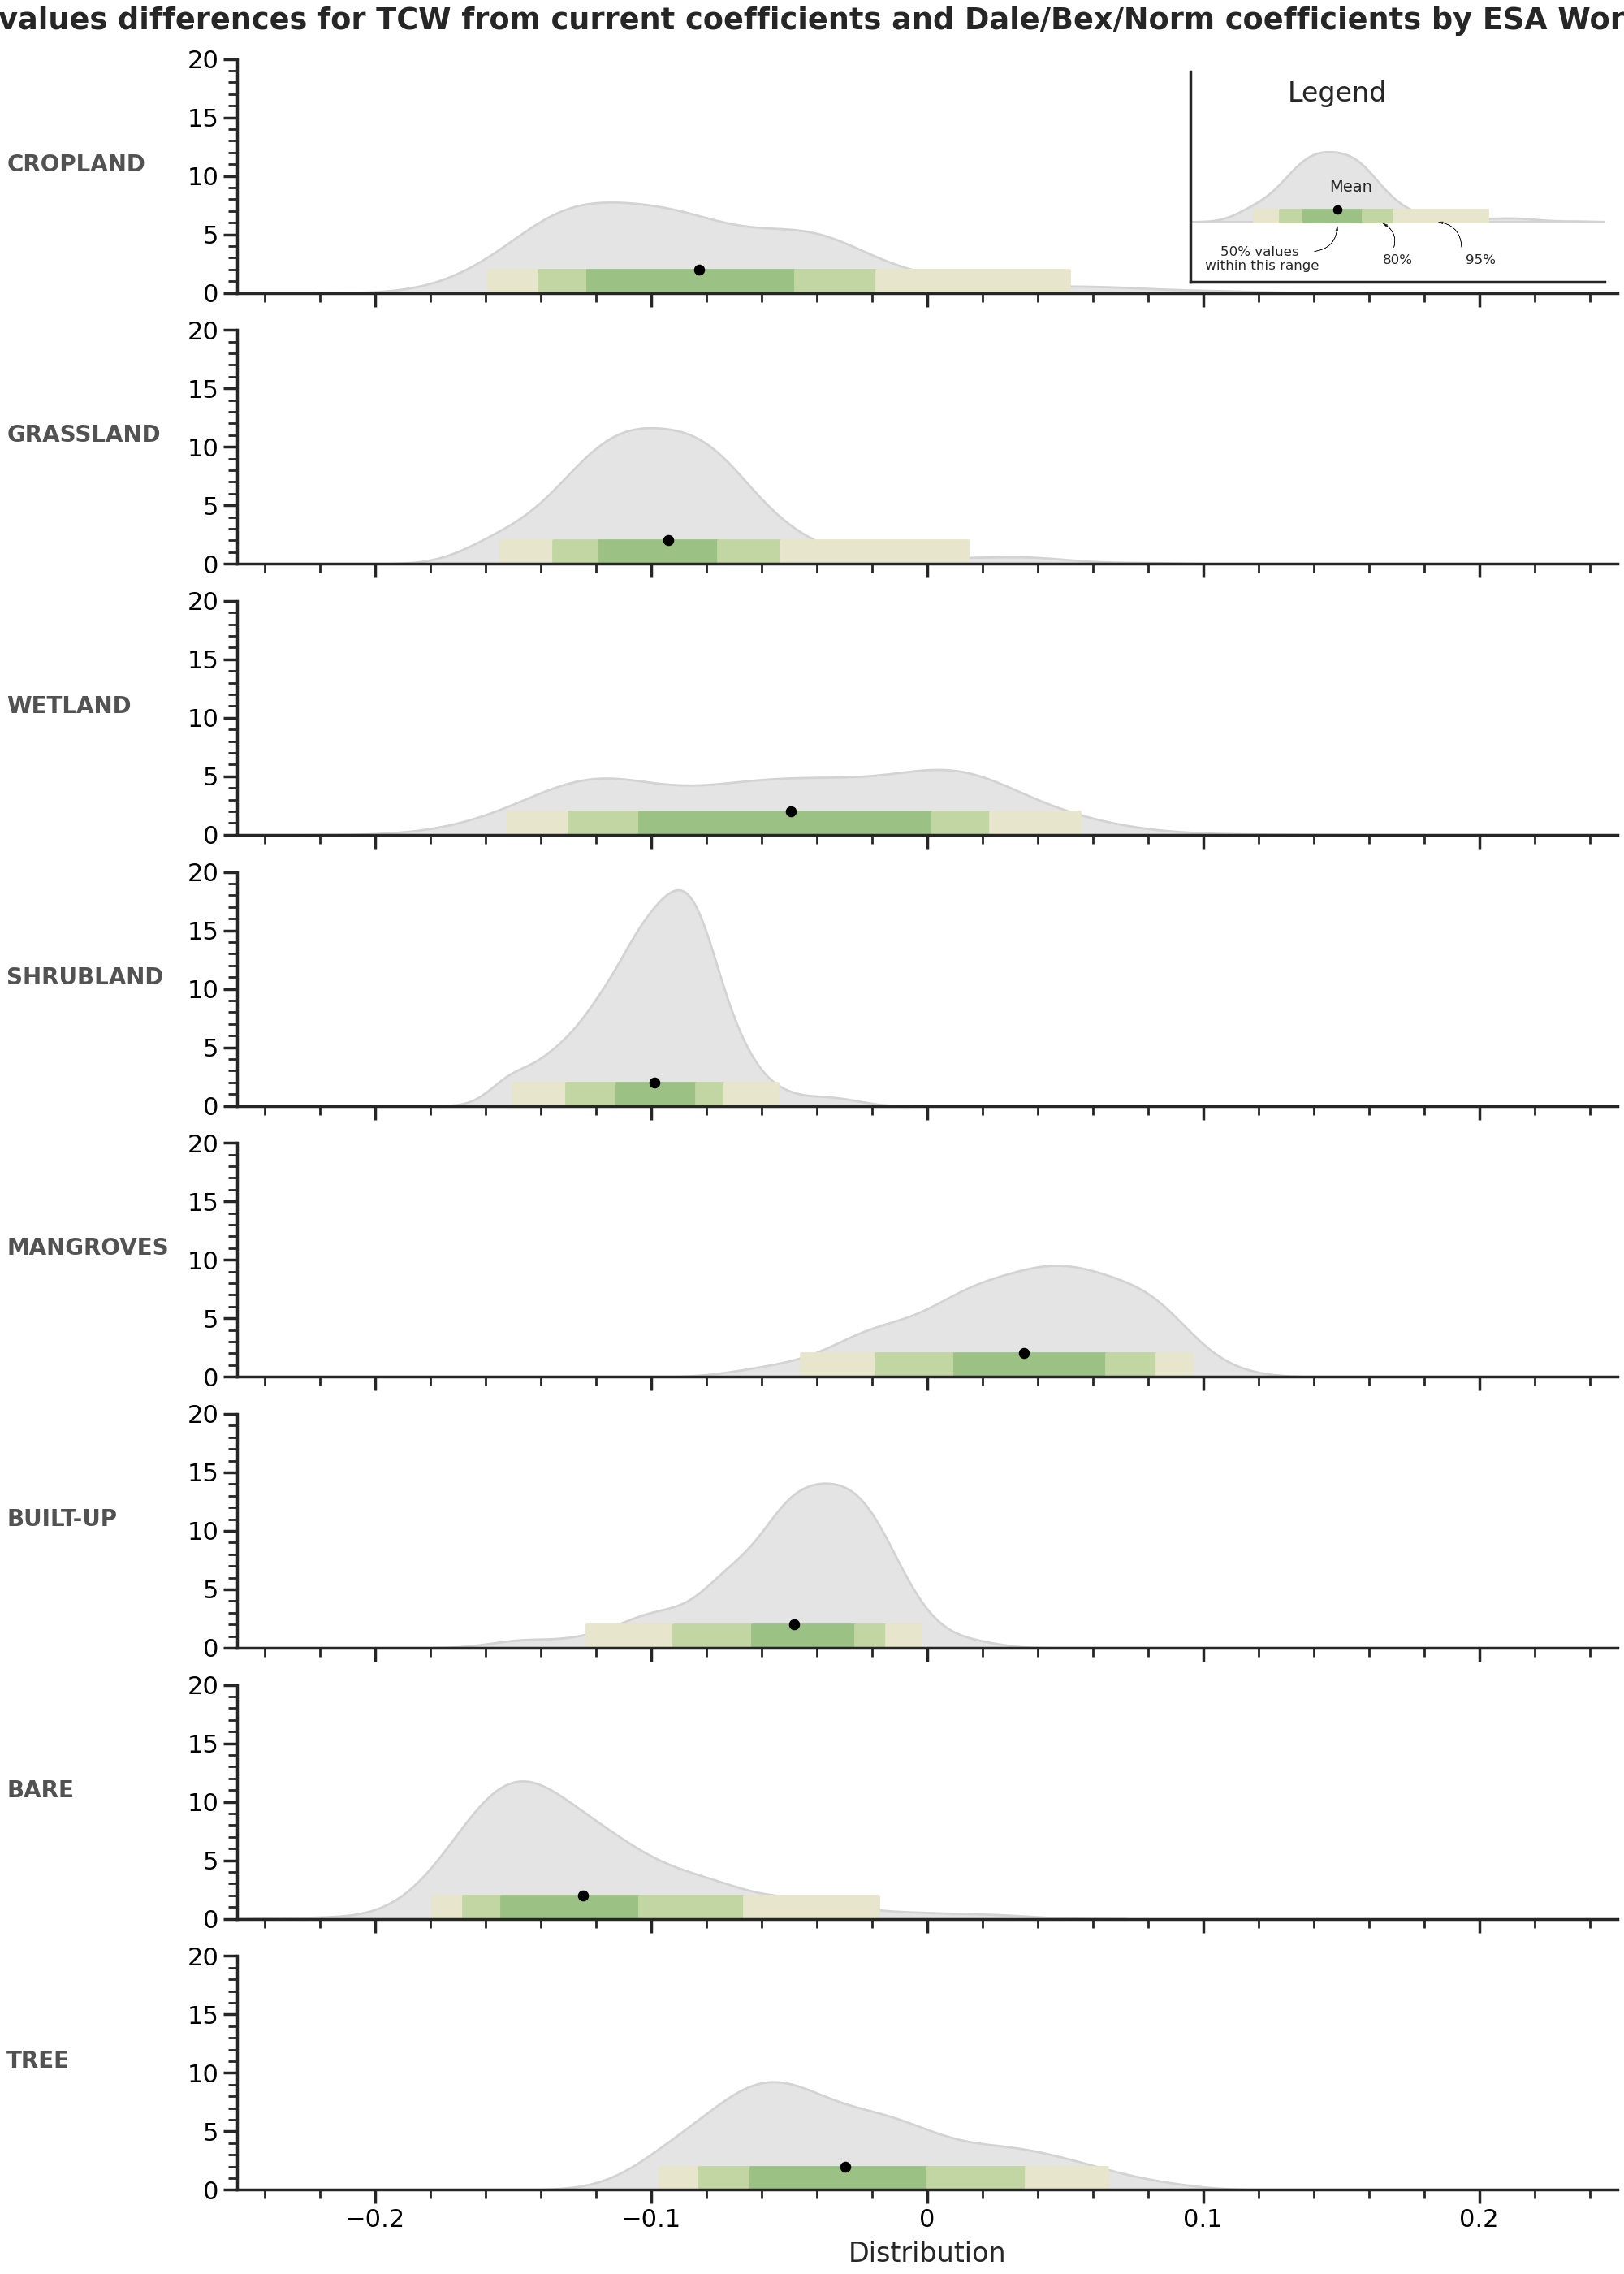

In [20]:
fig, axs = plt.subplots(nrows = len(classes), ncols=1, figsize=(10,14), layout='constrained', sharex=True)
axs = axs.flatten()


for i, cls in enumerate(classes):
    subset = combined_no_water_df[combined_no_water_df['classname'] == cls]

    sns.kdeplot(
        subset['diff_TCW_DEA'],
        shade=True,
        bw_adjust = bandwidth,
        ax = axs[i],
        color='grey',
        edgecolor='lightgrey',
    )


    # quantiles
    quantiles = np.percentile(subset['diff_TCW_DEA'], [2.5, 10, 25, 75, 90, 97.5])
    quantiles = list(quantiles)

    # fill space between each pair of quantiles
    for j in range(len(quantiles) - 1):
        axs[i].fill_between(
            [quantiles[j],
            quantiles[j + 1]],
            0,
            2,
            color=colors[j]
        )

    #add mean value as reference
    mean = subset['diff_TCW_DEA'].mean()
    axs[i].scatter([mean], [2], color='black', s=15)


    #title and labels
    axs[i].set_xlim(-0.25, 0.25)
    axs[i].set_ylim(0,20)
    axs[i].set_ylabel(cls.upper(), 
                      fontdict={'fontsize': 10, 'fontweight': 'bold', 'color': darkgrey}, 
                      rotation=0,
                     labelpad=80,
                     ha='left')
    axs[i].set_xlabel('Distribution')


# legend on the first ax
subax = inset_axes(
    parent_axes=axs[0],
    width="30%",
    height="90%",
    loc=1
)
subax.set_xticks([])
subax.set_yticks([])
legend_subset = combined_no_water_df[combined_no_water_df['classname'] == 'grassland']
sns.kdeplot(
    legend_subset['diff_TCW_DEA'],
    shade=True,
    ax=subax,
    color='grey',
    edgecolor='lightgrey'
)
quantiles = np.percentile(legend_subset['diff_TCW_DEA'], [2.5, 10, 25, 75, 90, 97.5])
quantiles = quantiles.tolist()
for j in range(len(quantiles) - 1):
    subax.fill_between(
        [quantiles[j], # lower bound
         quantiles[j+1]], # upper bound
        0, # max y=0
        2, # max y=0.00004
        color=colors[j]
    )
subax.set_xlim(-0.2, 0.1)
subax.set_ylim(-10, 25)
mean = legend_subset['diff_TCW_DEA'].mean()
subax.scatter([mean], [2], color='black', s=10)

subax.text(
    -0.13, 20,
    'Legend',
    ha='left',
    fontsize=12,
)


subax.text(
    mean+0.01, 5,
    'Mean',
    ha='center',
    fontsize=7,
)

subax.text(
    0.01, -7,
    "95%",
    ha='center',
    fontsize=6,
)

subax.text(
    -0.05, -7,
    "80%",
    ha='center',
    fontsize=6,
)
subax.text(
    -0.15, -8,
    "50% values\n within this range",
    ha='center',
    fontsize=6,
)

add_arrow((mean, 0), (mean - 0.02, -5), subax) #50%
add_arrow((mean+ 0.03, 0), (mean + 0.04, -5), subax) #80%
add_arrow((mean+0.07, 0), (mean + 0.09, -5), subax) #95%


fig.suptitle(f'Distribution of values differences for TCW from current coefficients and Dale/Bex/Norm coefficients by ESA Worldcover classes')
fig.savefig("distributions_TCW_current_dea_by_esa_worldcover.png", dpi=100, bbox_inches='tight')
#plt.close()

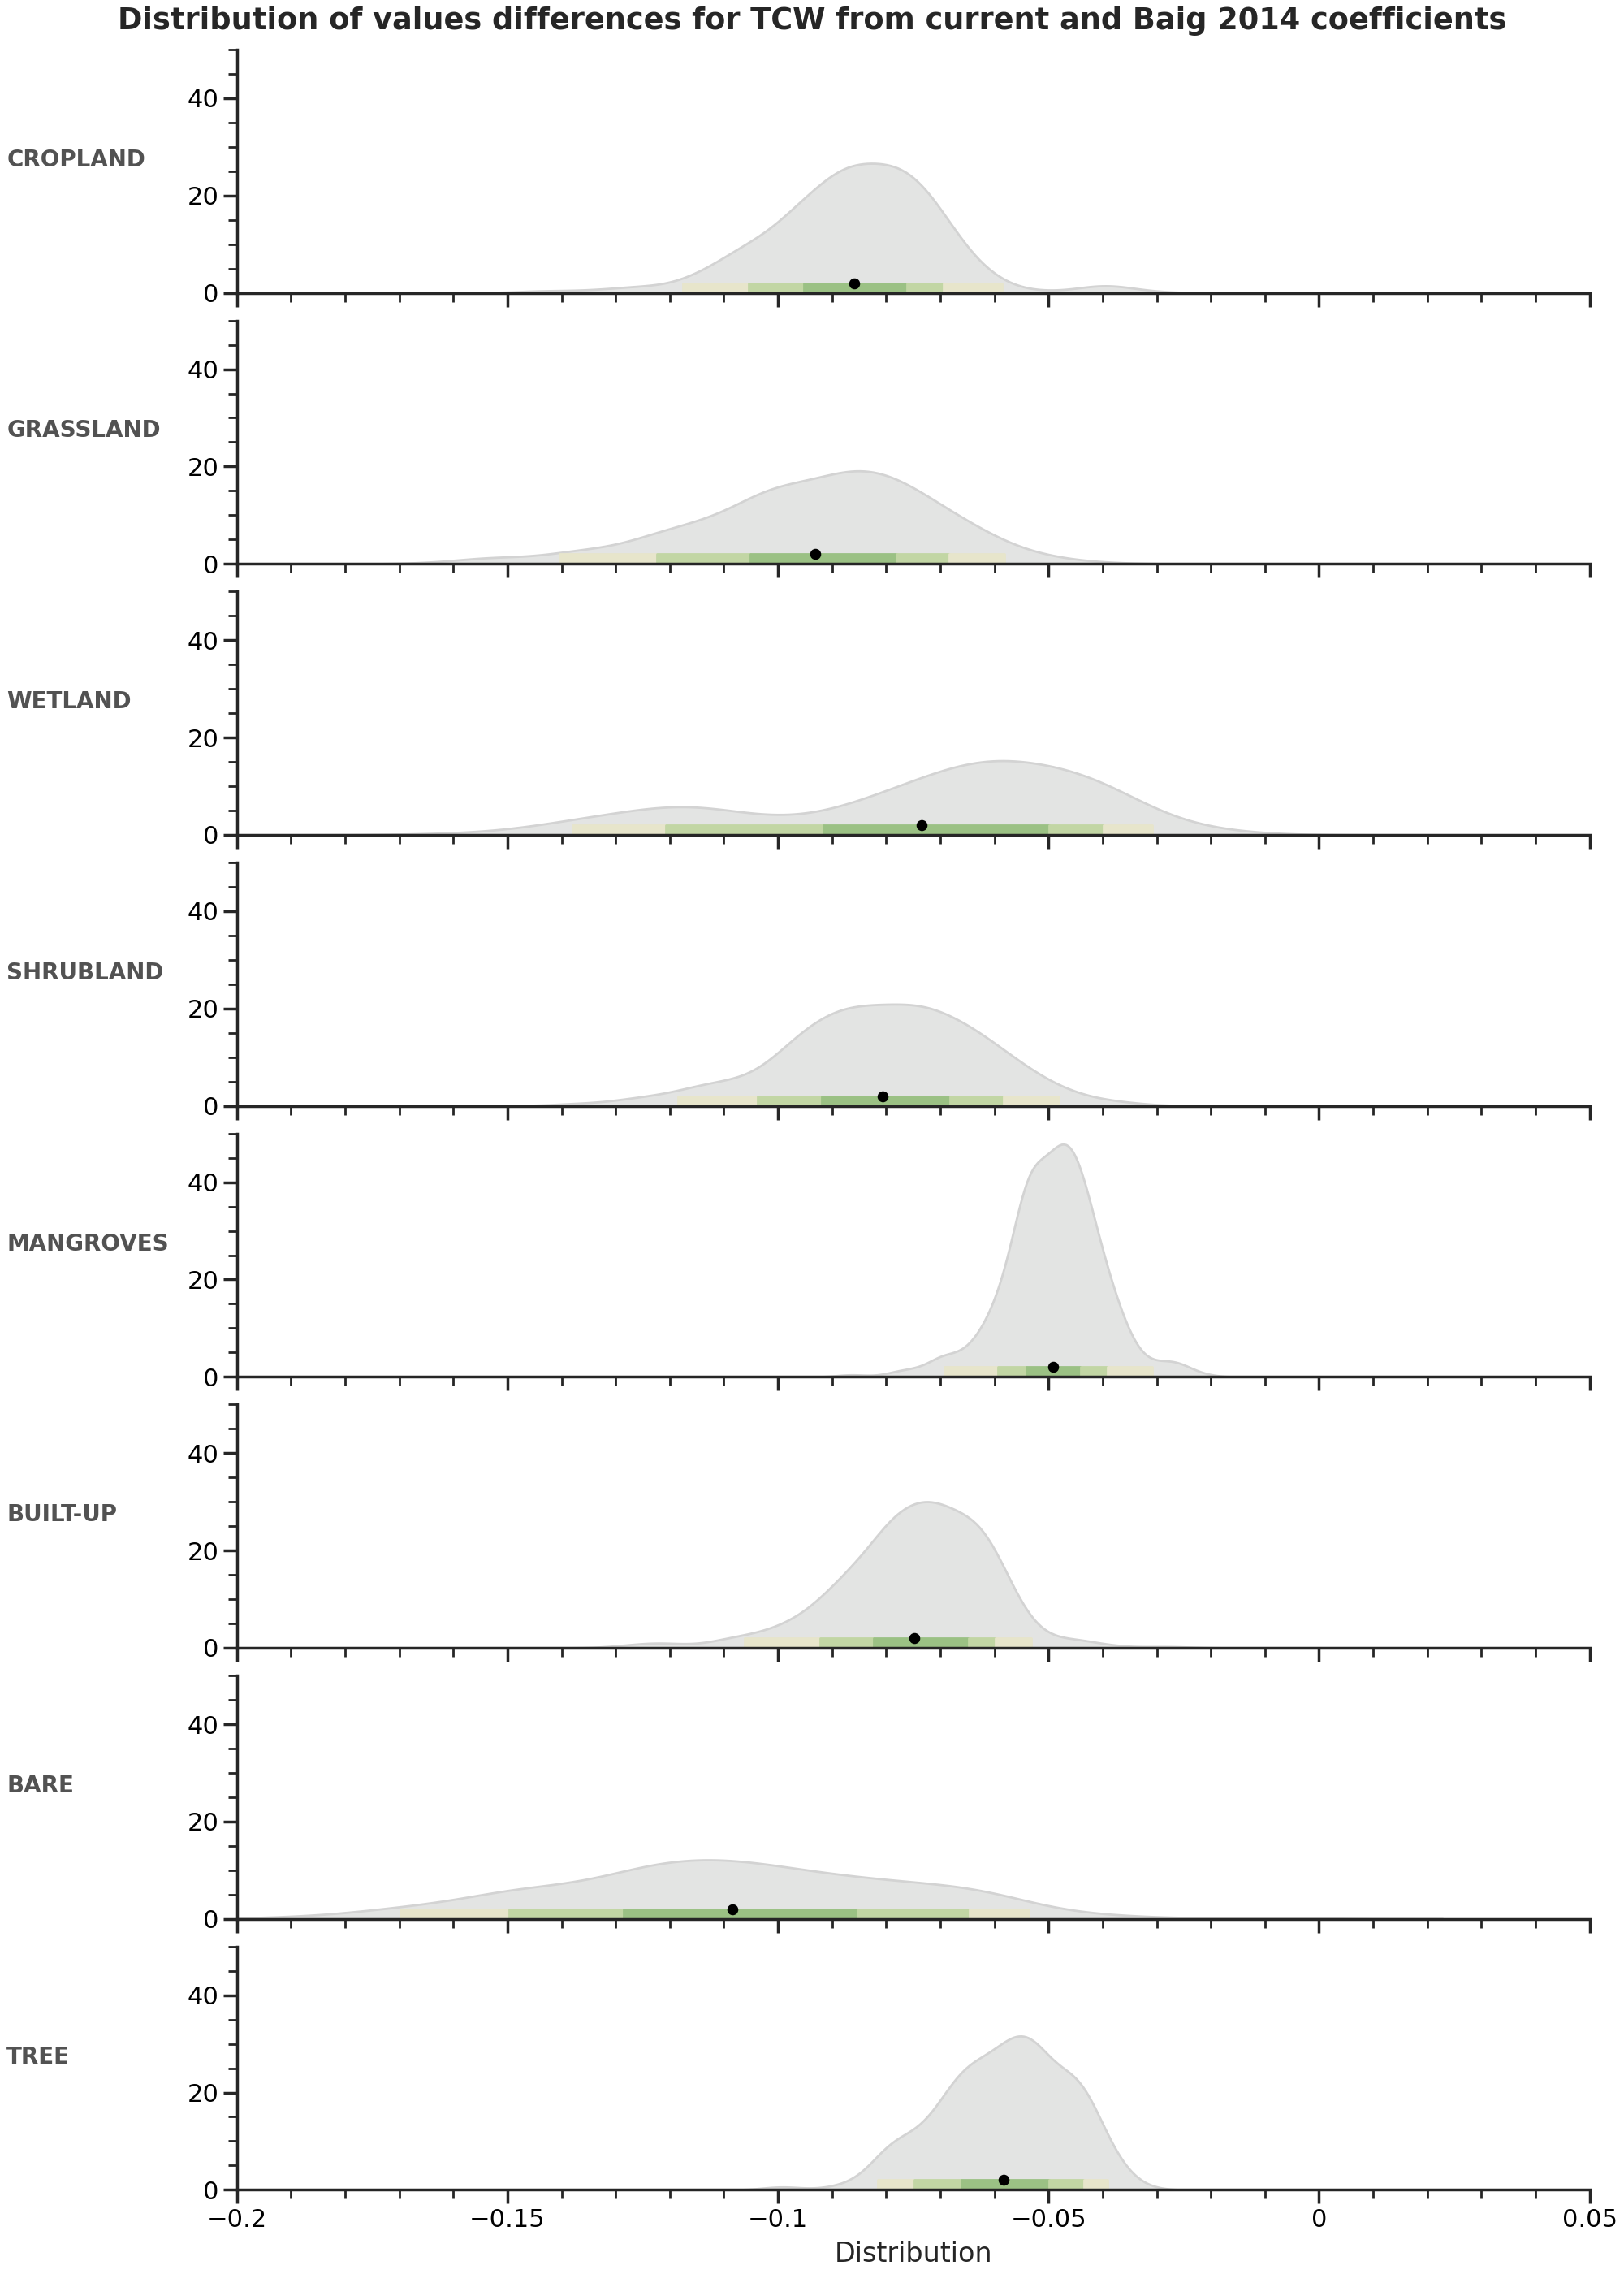

In [34]:
fig, axs = plt.subplots(nrows = len(classes), ncols=1, figsize=(10,14), layout='constrained', sharex=True)
axs = axs.flatten()


for i, cls in enumerate(classes):
    subset = combined_no_water_df[combined_no_water_df['classname'] == cls]

    sns.kdeplot(
        subset['diff_TCW_ls8'],
        shade=True,
        bw_adjust = bandwidth,
        ax = axs[i],
        color='grey',
        edgecolor='lightgrey',
    )


    # quantiles
    quantiles = np.percentile(subset['diff_TCW_ls8'], [2.5, 10, 25, 75, 90, 97.5])
    quantiles = list(quantiles)

    # fill space between each pair of quantiles
    for j in range(len(quantiles) - 1):
        axs[i].fill_between(
            [quantiles[j],
            quantiles[j + 1]],
            0,
            2,
            color=colors[j]
        )

    #add mean value as reference
    mean = subset['diff_TCW_ls8'].mean()
    axs[i].scatter([mean], [2], color='black', s=15)


    #title and labels
    axs[i].set_xlim(-0.2, 0.05)
    axs[i].set_ylim(0,50)
    axs[i].set_ylabel(cls.upper(), 
                      fontdict={'fontsize': 10, 'fontweight': 'bold', 'color': darkgrey}, 
                      rotation=0,
                     labelpad=80,
                     ha='left')
    axs[i].set_xlabel('Distribution')



fig.suptitle(f'Distribution of values differences for TCW from current and Baig 2014 coefficients')
fig.savefig("distributions_TCW_current_baig_by_esa_worldcover.png", dpi=100, bbox_inches='tight')
#plt.close()

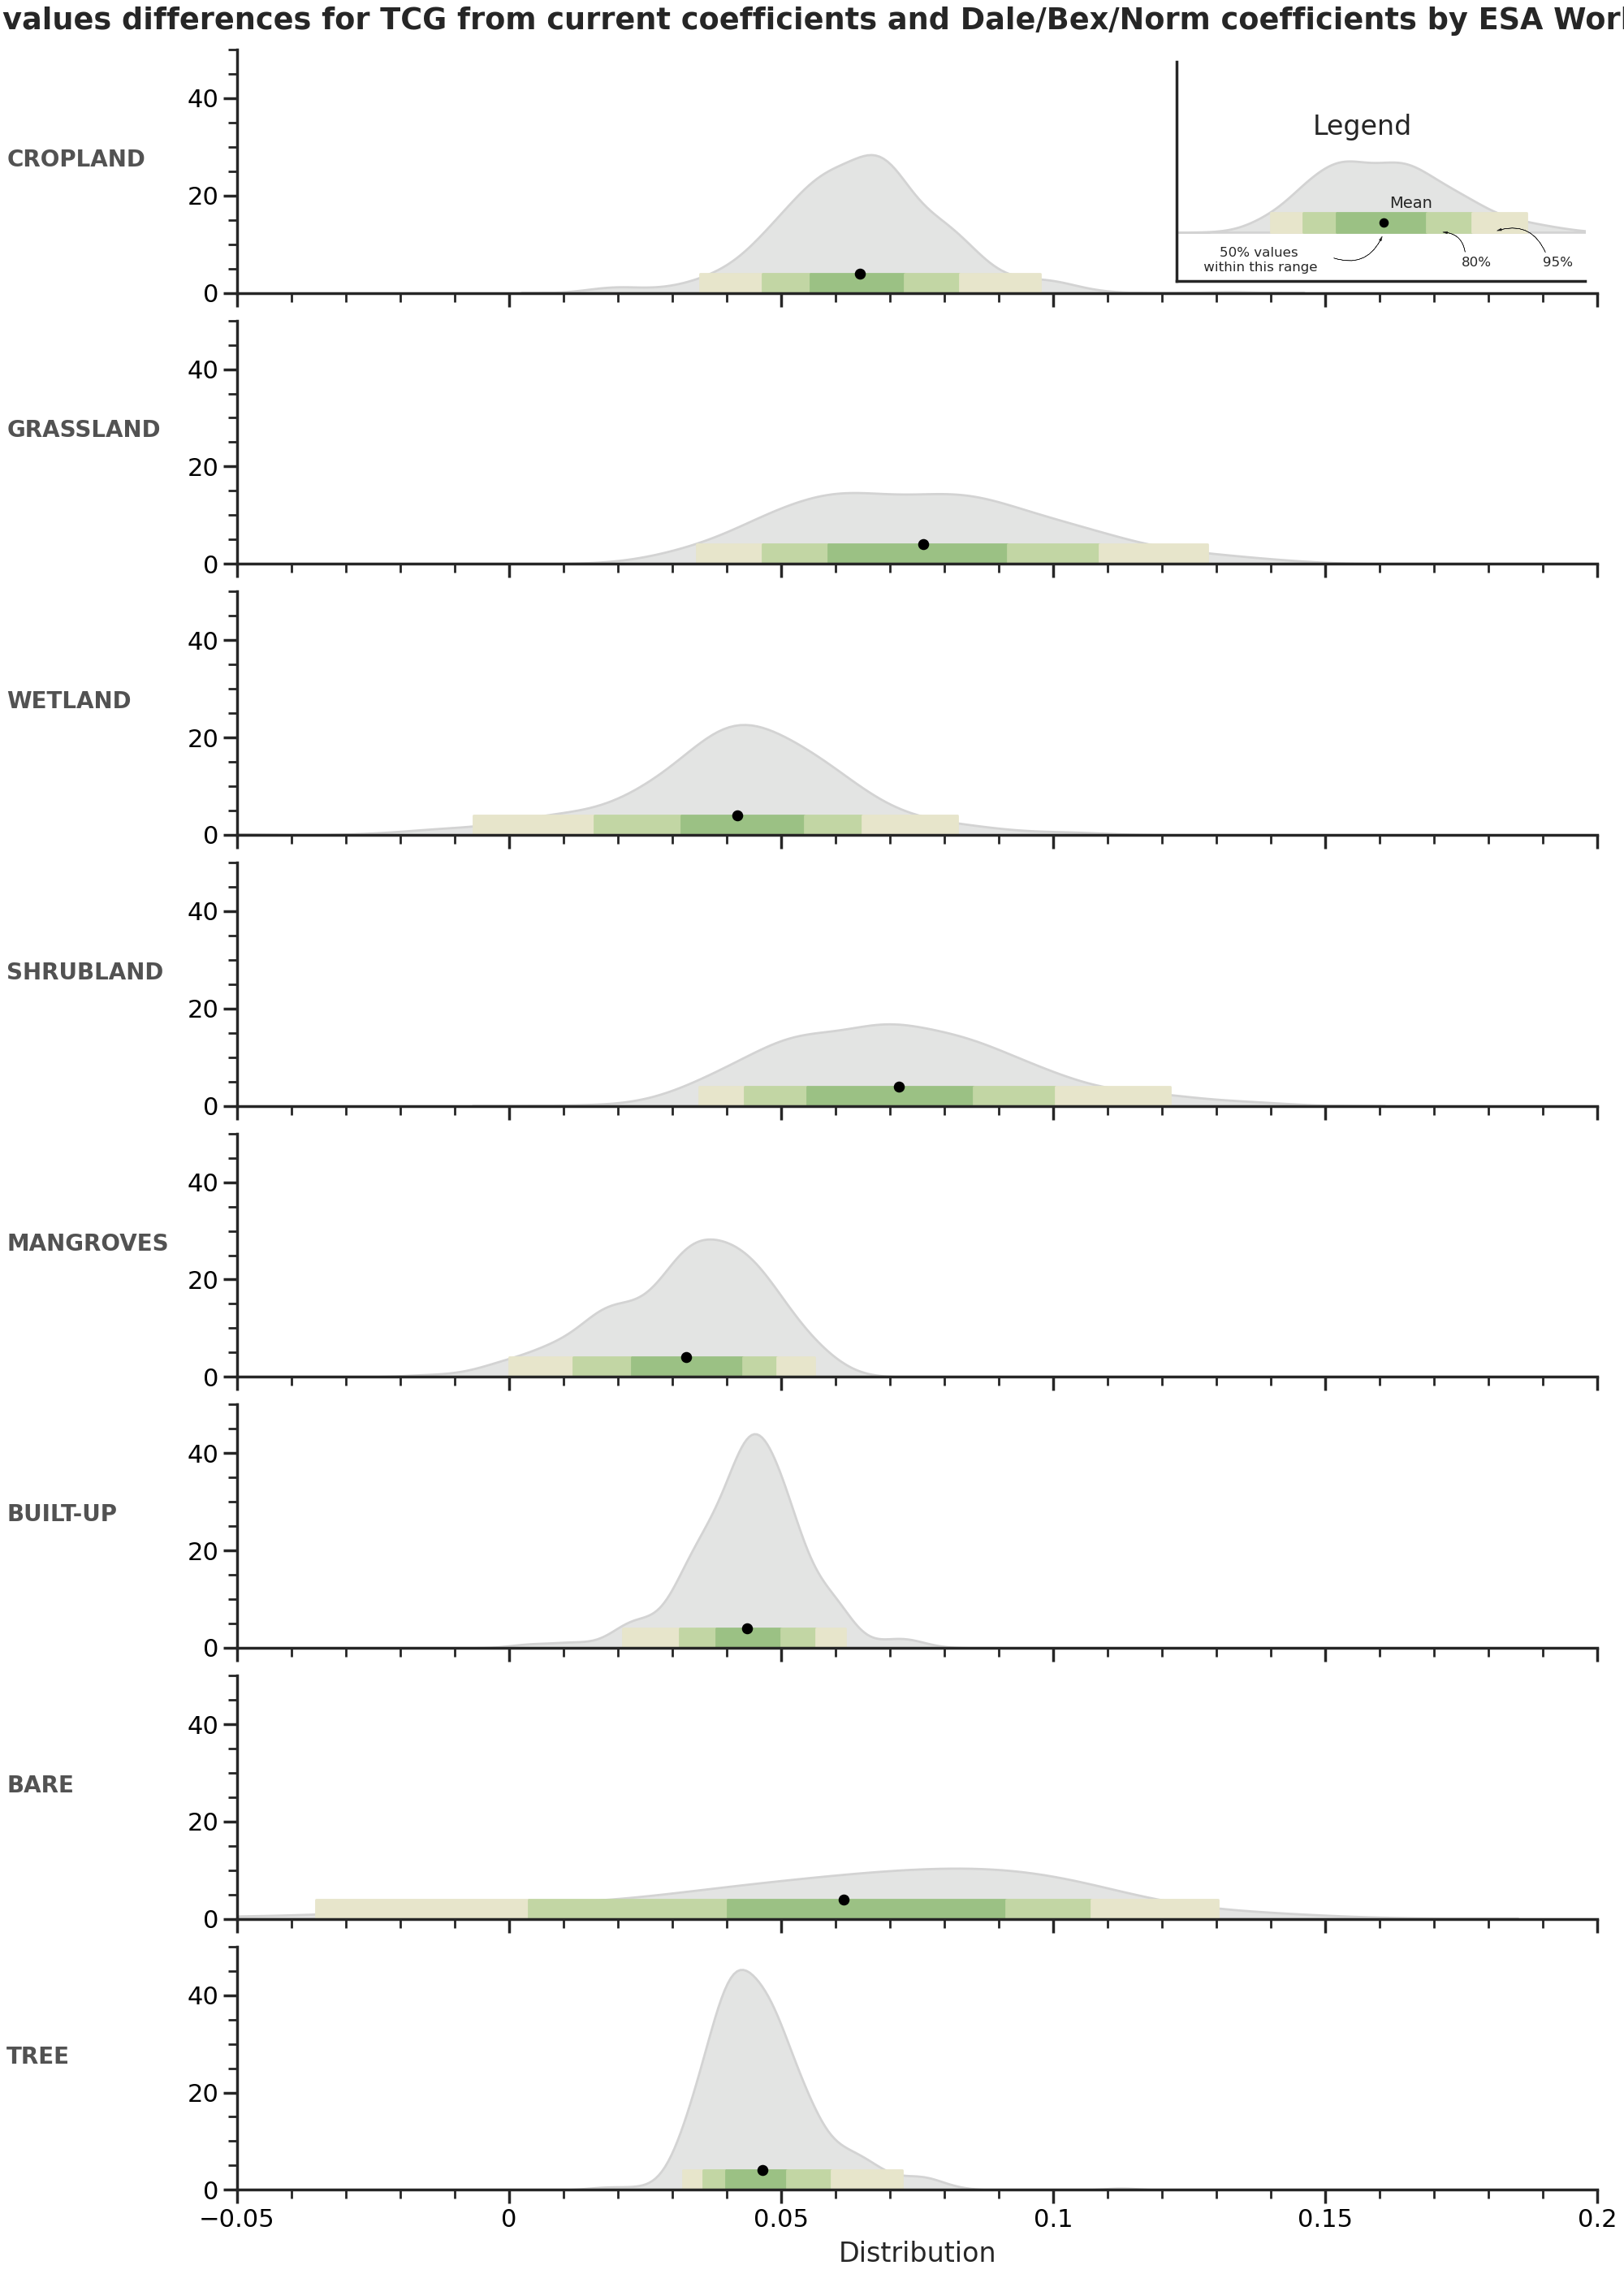

In [21]:
fig, axs = plt.subplots(nrows = len(classes), ncols=1, figsize=(10,14), layout='constrained', sharex=True)
axs = axs.flatten()


for i, cls in enumerate(classes):
    subset = combined_no_water_df[combined_no_water_df['classname'] == cls]

    sns.kdeplot(
        subset['diff_TCG_DEA'],
        shade=True,
        bw_adjust = bandwidth,
        ax = axs[i],
        color='grey',
        edgecolor='lightgrey',
    )


    # quantiles
    quantiles = np.percentile(subset['diff_TCG_DEA'], [2.5, 10, 25, 75, 90, 97.5])
    quantiles = list(quantiles)

    # fill space between each pair of quantiles
    for j in range(len(quantiles) - 1):
        axs[i].fill_between(
            [quantiles[j],
            quantiles[j + 1]],
            0,
            4,
            color=colors[j]
        )

    #add mean value as reference
    mean = subset['diff_TCG_DEA'].mean()
    axs[i].scatter([mean], [4], color='black', s=15)


    #title and labels
    axs[i].set_xlim(-0.05, 0.2)
    axs[i].set_ylim(0,50)
    axs[i].set_ylabel(cls.upper(), 
                      fontdict={'fontsize': 10, 'fontweight': 'bold', 'color': darkgrey}, 
                      rotation=0,
                     labelpad=80,
                     ha='left')
    axs[i].set_xlabel('Distribution')


# legend on the first ax
subax = inset_axes(
    parent_axes=axs[0],
    width="30%",
    height="90%",
    loc=1
)
subax.set_xticks([])
subax.set_yticks([])
legend_subset = combined_no_water_df[combined_no_water_df['classname'] == 'grassland']
sns.kdeplot(
    legend_subset['diff_TCG_DEA'],
    shade=True,
    ax=subax,
    color='grey',
    edgecolor='lightgrey'
)
quantiles = np.percentile(legend_subset['diff_TCG_DEA'], [2.5, 10, 25, 75, 90, 97.5])
quantiles = quantiles.tolist()
for j in range(len(quantiles) - 1):
    subax.fill_between(
        [quantiles[j], # lower bound
         quantiles[j+1]], # upper bound
        0, # max y=0
        4, # max y=0.00004
        color=colors[j]
    )
subax.set_xlim(0, 0.15)
subax.set_ylim(-10, 35)
mean = legend_subset['diff_TCG_DEA'].mean()
subax.scatter([mean], [2], color='black', s=10)

subax.text(
    0.05, 20,
    'Legend',
    ha='left',
    fontsize=12,
)


subax.text(
    mean+0.01, 5,
    'Mean',
    ha='center',
    fontsize=7,
)

subax.text(
    0.14, -7,
    "95%",
    ha='center',
    fontsize=6,
)

subax.text(
    0.11, -7,
    "80%",
    ha='center',
    fontsize=6,
)
subax.text(
    0.03, -8,
    "50% values\n within this range",
    ha='center',
    fontsize=6,
)

add_arrow((mean, 0), (mean - 0.02, -5), subax) #50%
add_arrow((mean+ 0.02, 0), (mean + 0.03, -5), subax) #80%
add_arrow((mean+0.04, 0), (mean + 0.06, -5), subax) #95%


fig.suptitle(f'Distribution of values differences for TCG from current coefficients and Dale/Bex/Norm coefficients by ESA Worldcover classes')
fig.savefig("distributions_TCG_current_dea_by_esa_worldcover.png", dpi=100, bbox_inches='tight')
#plt.close()


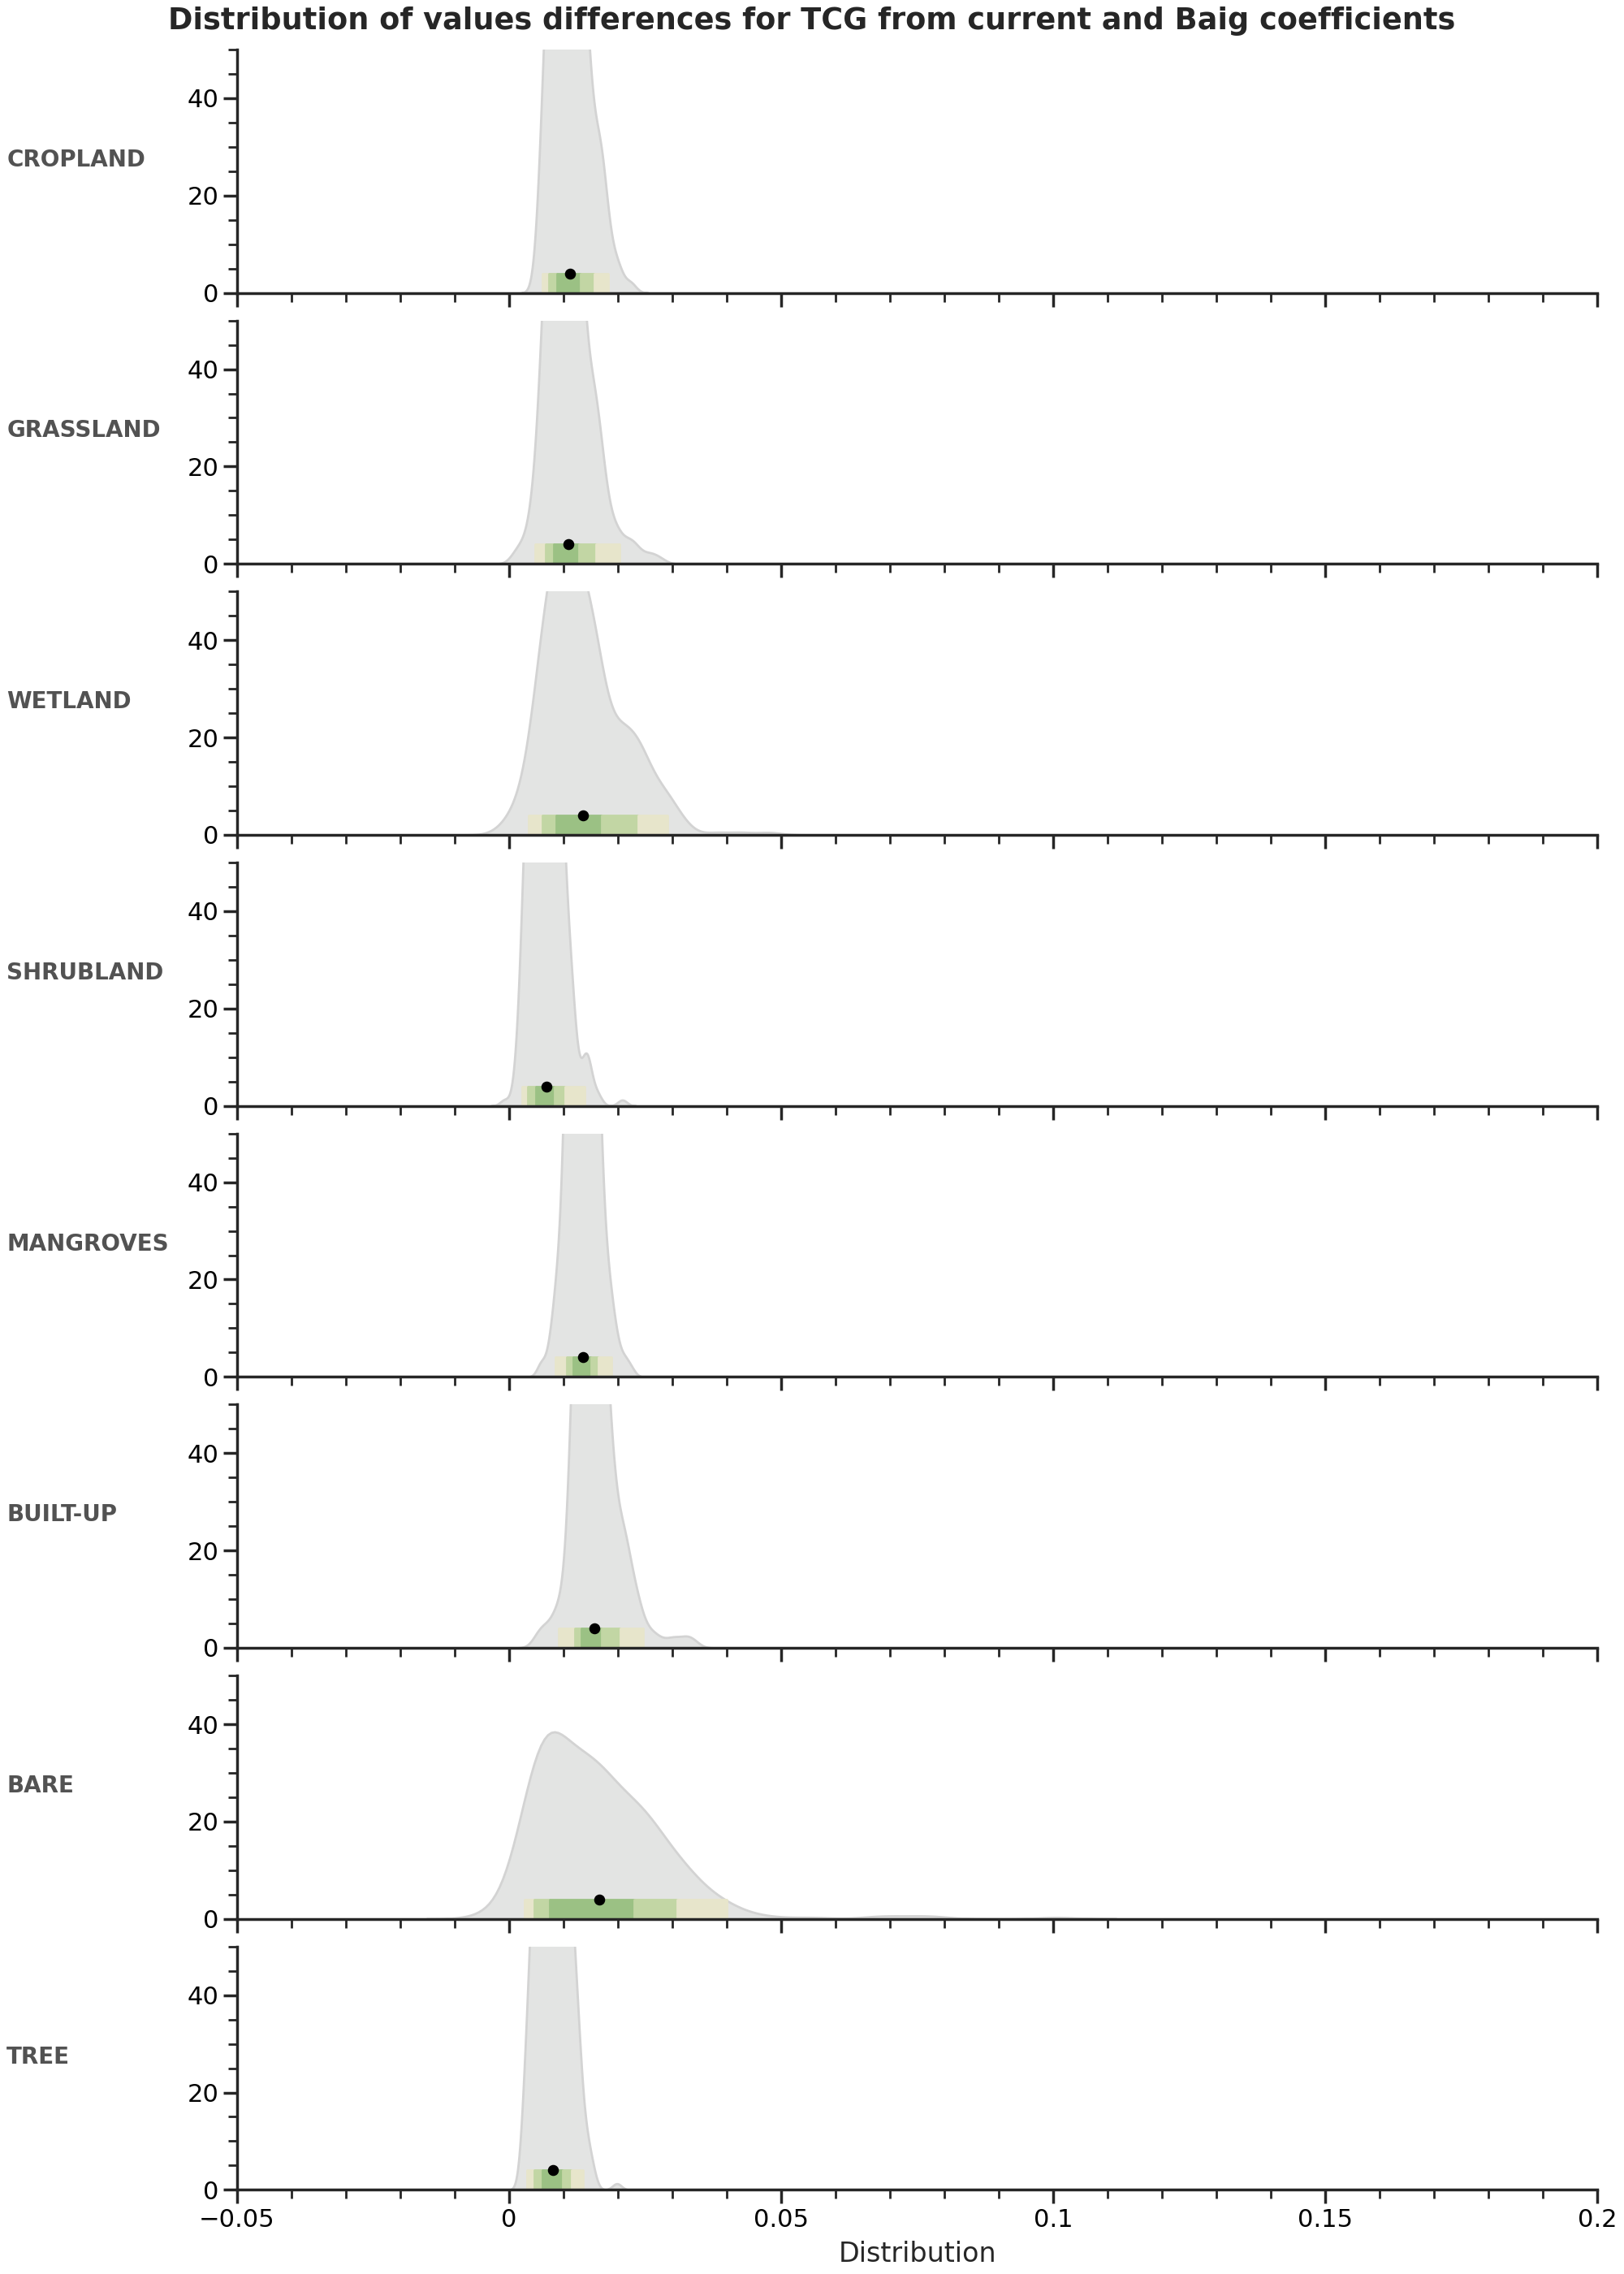

In [31]:
fig, axs = plt.subplots(nrows = len(classes), ncols=1, figsize=(10,14), layout='constrained', sharex=True)
axs = axs.flatten()


for i, cls in enumerate(classes):
    subset = combined_no_water_df[combined_no_water_df['classname'] == cls]

    sns.kdeplot(
        subset['diff_TCG_ls8'],
        shade=True,
        bw_adjust = bandwidth,
        ax = axs[i],
        color='grey',
        edgecolor='lightgrey',
    )


    # quantiles
    quantiles = np.percentile(subset['diff_TCG_ls8'], [2.5, 10, 25, 75, 90, 97.5])
    quantiles = list(quantiles)

    # fill space between each pair of quantiles
    for j in range(len(quantiles) - 1):
        axs[i].fill_between(
            [quantiles[j],
            quantiles[j + 1]],
            0,
            4,
            color=colors[j]
        )

    #add mean value as reference
    mean = subset['diff_TCG_ls8'].mean()
    axs[i].scatter([mean], [4], color='black', s=15)


    #title and labels
    axs[i].set_xlim(-0.05, 0.2)
    axs[i].set_ylim(0,50)
    axs[i].set_ylabel(cls.upper(), 
                      fontdict={'fontsize': 10, 'fontweight': 'bold', 'color': darkgrey}, 
                      rotation=0,
                     labelpad=80,
                     ha='left')
    axs[i].set_xlabel('Distribution')



fig.suptitle(f'Distribution of values differences for TCG from current and Baig coefficients')
fig.savefig("distributions_TCG_current_baig_by_esa_worldcover.png", dpi=100, bbox_inches='tight')
#plt.close()


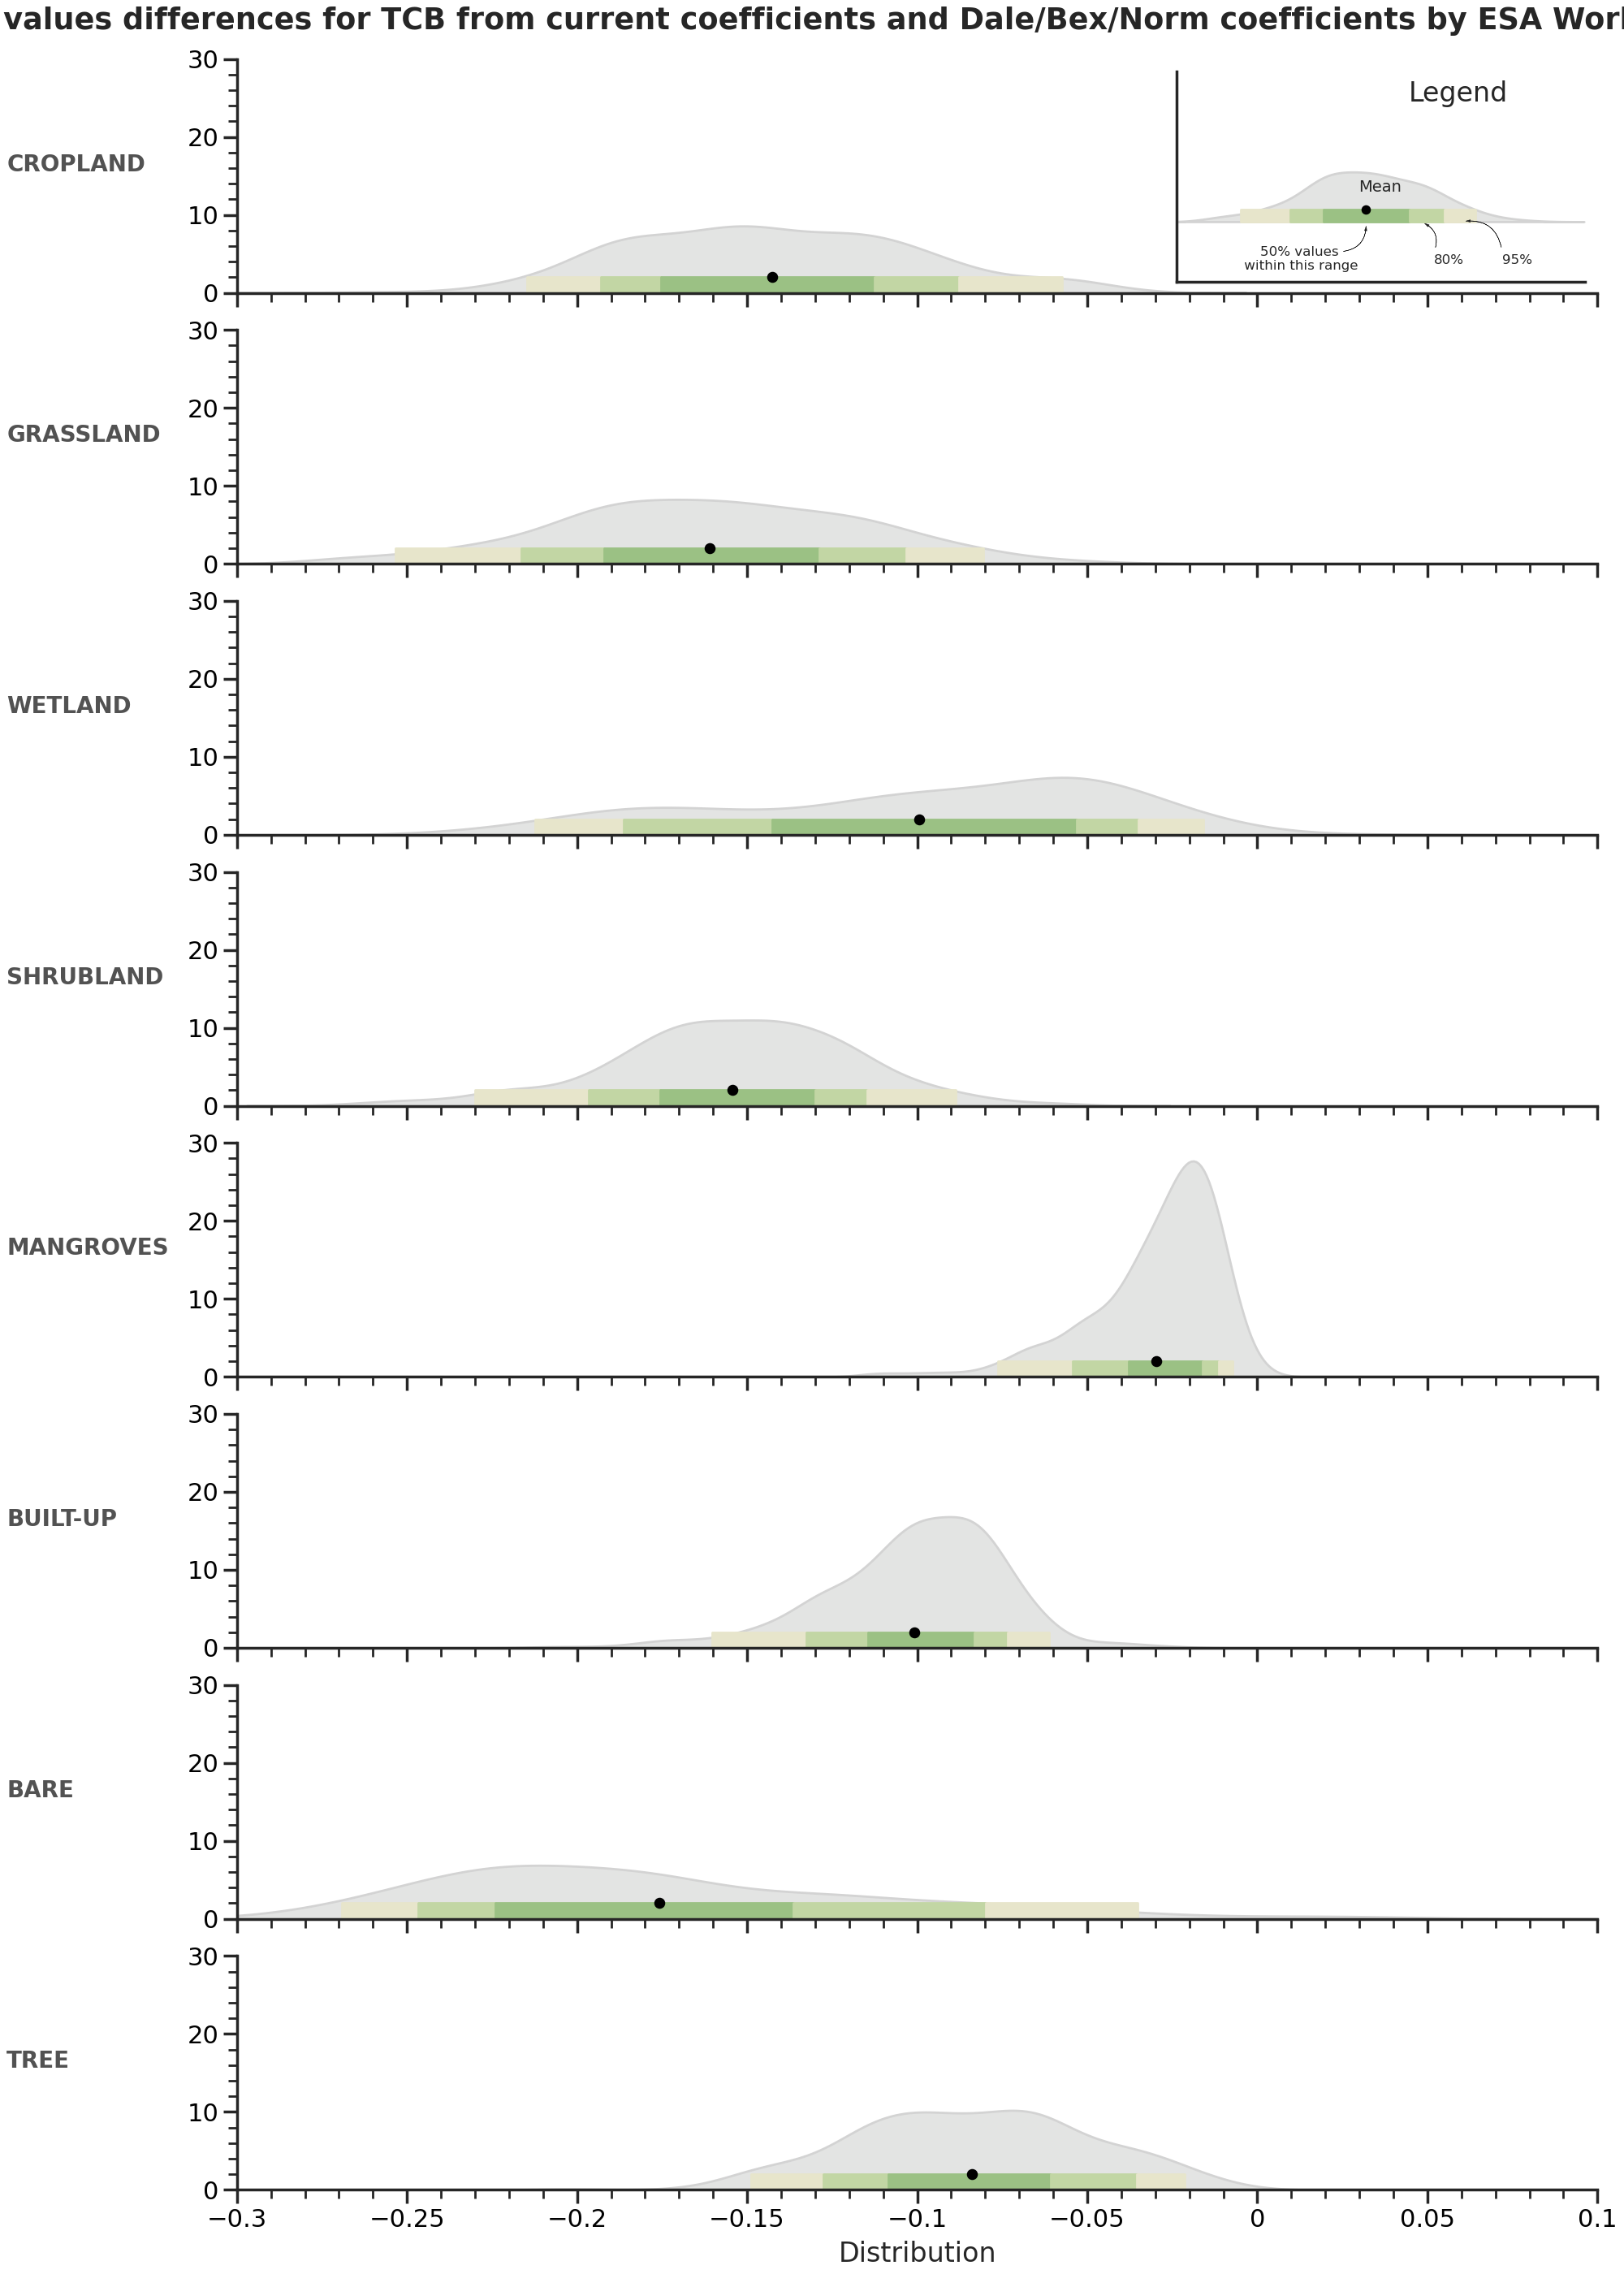

In [22]:
fig, axs = plt.subplots(nrows = len(classes), ncols=1, figsize=(10,14), layout='constrained', sharex=True)
axs = axs.flatten()


for i, cls in enumerate(classes):
    subset = combined_no_water_df[combined_no_water_df['classname'] == cls]

    sns.kdeplot(
        subset['diff_TCB_DEA'],
        shade=True,
        bw_adjust = bandwidth,
        ax = axs[i],
        color='grey',
        edgecolor='lightgrey',
    )


    # quantiles
    quantiles = np.percentile(subset['diff_TCB_DEA'], [2.5, 10, 25, 75, 90, 97.5])
    quantiles = list(quantiles)

    # fill space between each pair of quantiles
    for j in range(len(quantiles) - 1):
        axs[i].fill_between(
            [quantiles[j],
            quantiles[j + 1]],
            0,
            2,
            color=colors[j]
        )

    #add mean value as reference
    mean = subset['diff_TCB_DEA'].mean()
    axs[i].scatter([mean], [2], color='black', s=15)


    #title and labels
    axs[i].set_xlim(-0.3, 0.1)
    axs[i].set_ylim(0,30)
    axs[i].set_ylabel(cls.upper(), 
                      fontdict={'fontsize': 10, 'fontweight': 'bold', 'color': darkgrey}, 
                      rotation=0,
                     labelpad=80,
                     ha='left')
    axs[i].set_xlabel('Distribution')


# legend on the first ax
subax = inset_axes(
    parent_axes=axs[0],
    width="30%",
    height="90%",
    loc=1
)
subax.set_xticks([])
subax.set_yticks([])
legend_subset = combined_no_water_df[combined_no_water_df['classname'] == 'grassland']
sns.kdeplot(
    legend_subset['diff_TCB_DEA'],
    shade=True,
    ax=subax,
    color='grey',
    edgecolor='lightgrey'
)
quantiles = np.percentile(legend_subset['diff_TCB_DEA'], [2.5, 10, 25, 75, 90, 97.5])
quantiles = quantiles.tolist()
for j in range(len(quantiles) - 1):
    subax.fill_between(
        [quantiles[j], # lower bound
         quantiles[j+1]], # upper bound
        0, # max y=0
        2, # max y=0.00004
        color=colors[j]
    )
subax.set_xlim(-0.3, 0)
subax.set_ylim(-10, 25)
mean = legend_subset['diff_TCB_DEA'].mean()
subax.scatter([mean], [2], color='black', s=10)

subax.text(
    -0.13, 20,
    'Legend',
    ha='left',
    fontsize=12,
)


subax.text(
    mean+0.01, 5,
    'Mean',
    ha='center',
    fontsize=7,
)

subax.text(
    -0.05, -7,
    "95%",
    ha='center',
    fontsize=6,
)

subax.text(
    -0.1, -7,
    "80%",
    ha='center',
    fontsize=6,
)
subax.text(
    -0.21, -8,
    "50% values\n within this range",
    ha='center',
    fontsize=6,
)

add_arrow((mean, 0), (mean - 0.02, -5), subax) #50%
add_arrow((mean+ 0.04, 0), (mean + 0.05, -5), subax) #80%
add_arrow((mean+0.07, 0), (mean + 0.1, -5), subax) #95%


fig.suptitle(f'Distribution of values differences for TCB from current coefficients and Dale/Bex/Norm coefficients by ESA Worldcover classes')
fig.savefig("distributions_TCB_current_dea_by_esa_worldcover.png", dpi=100, bbox_inches='tight')



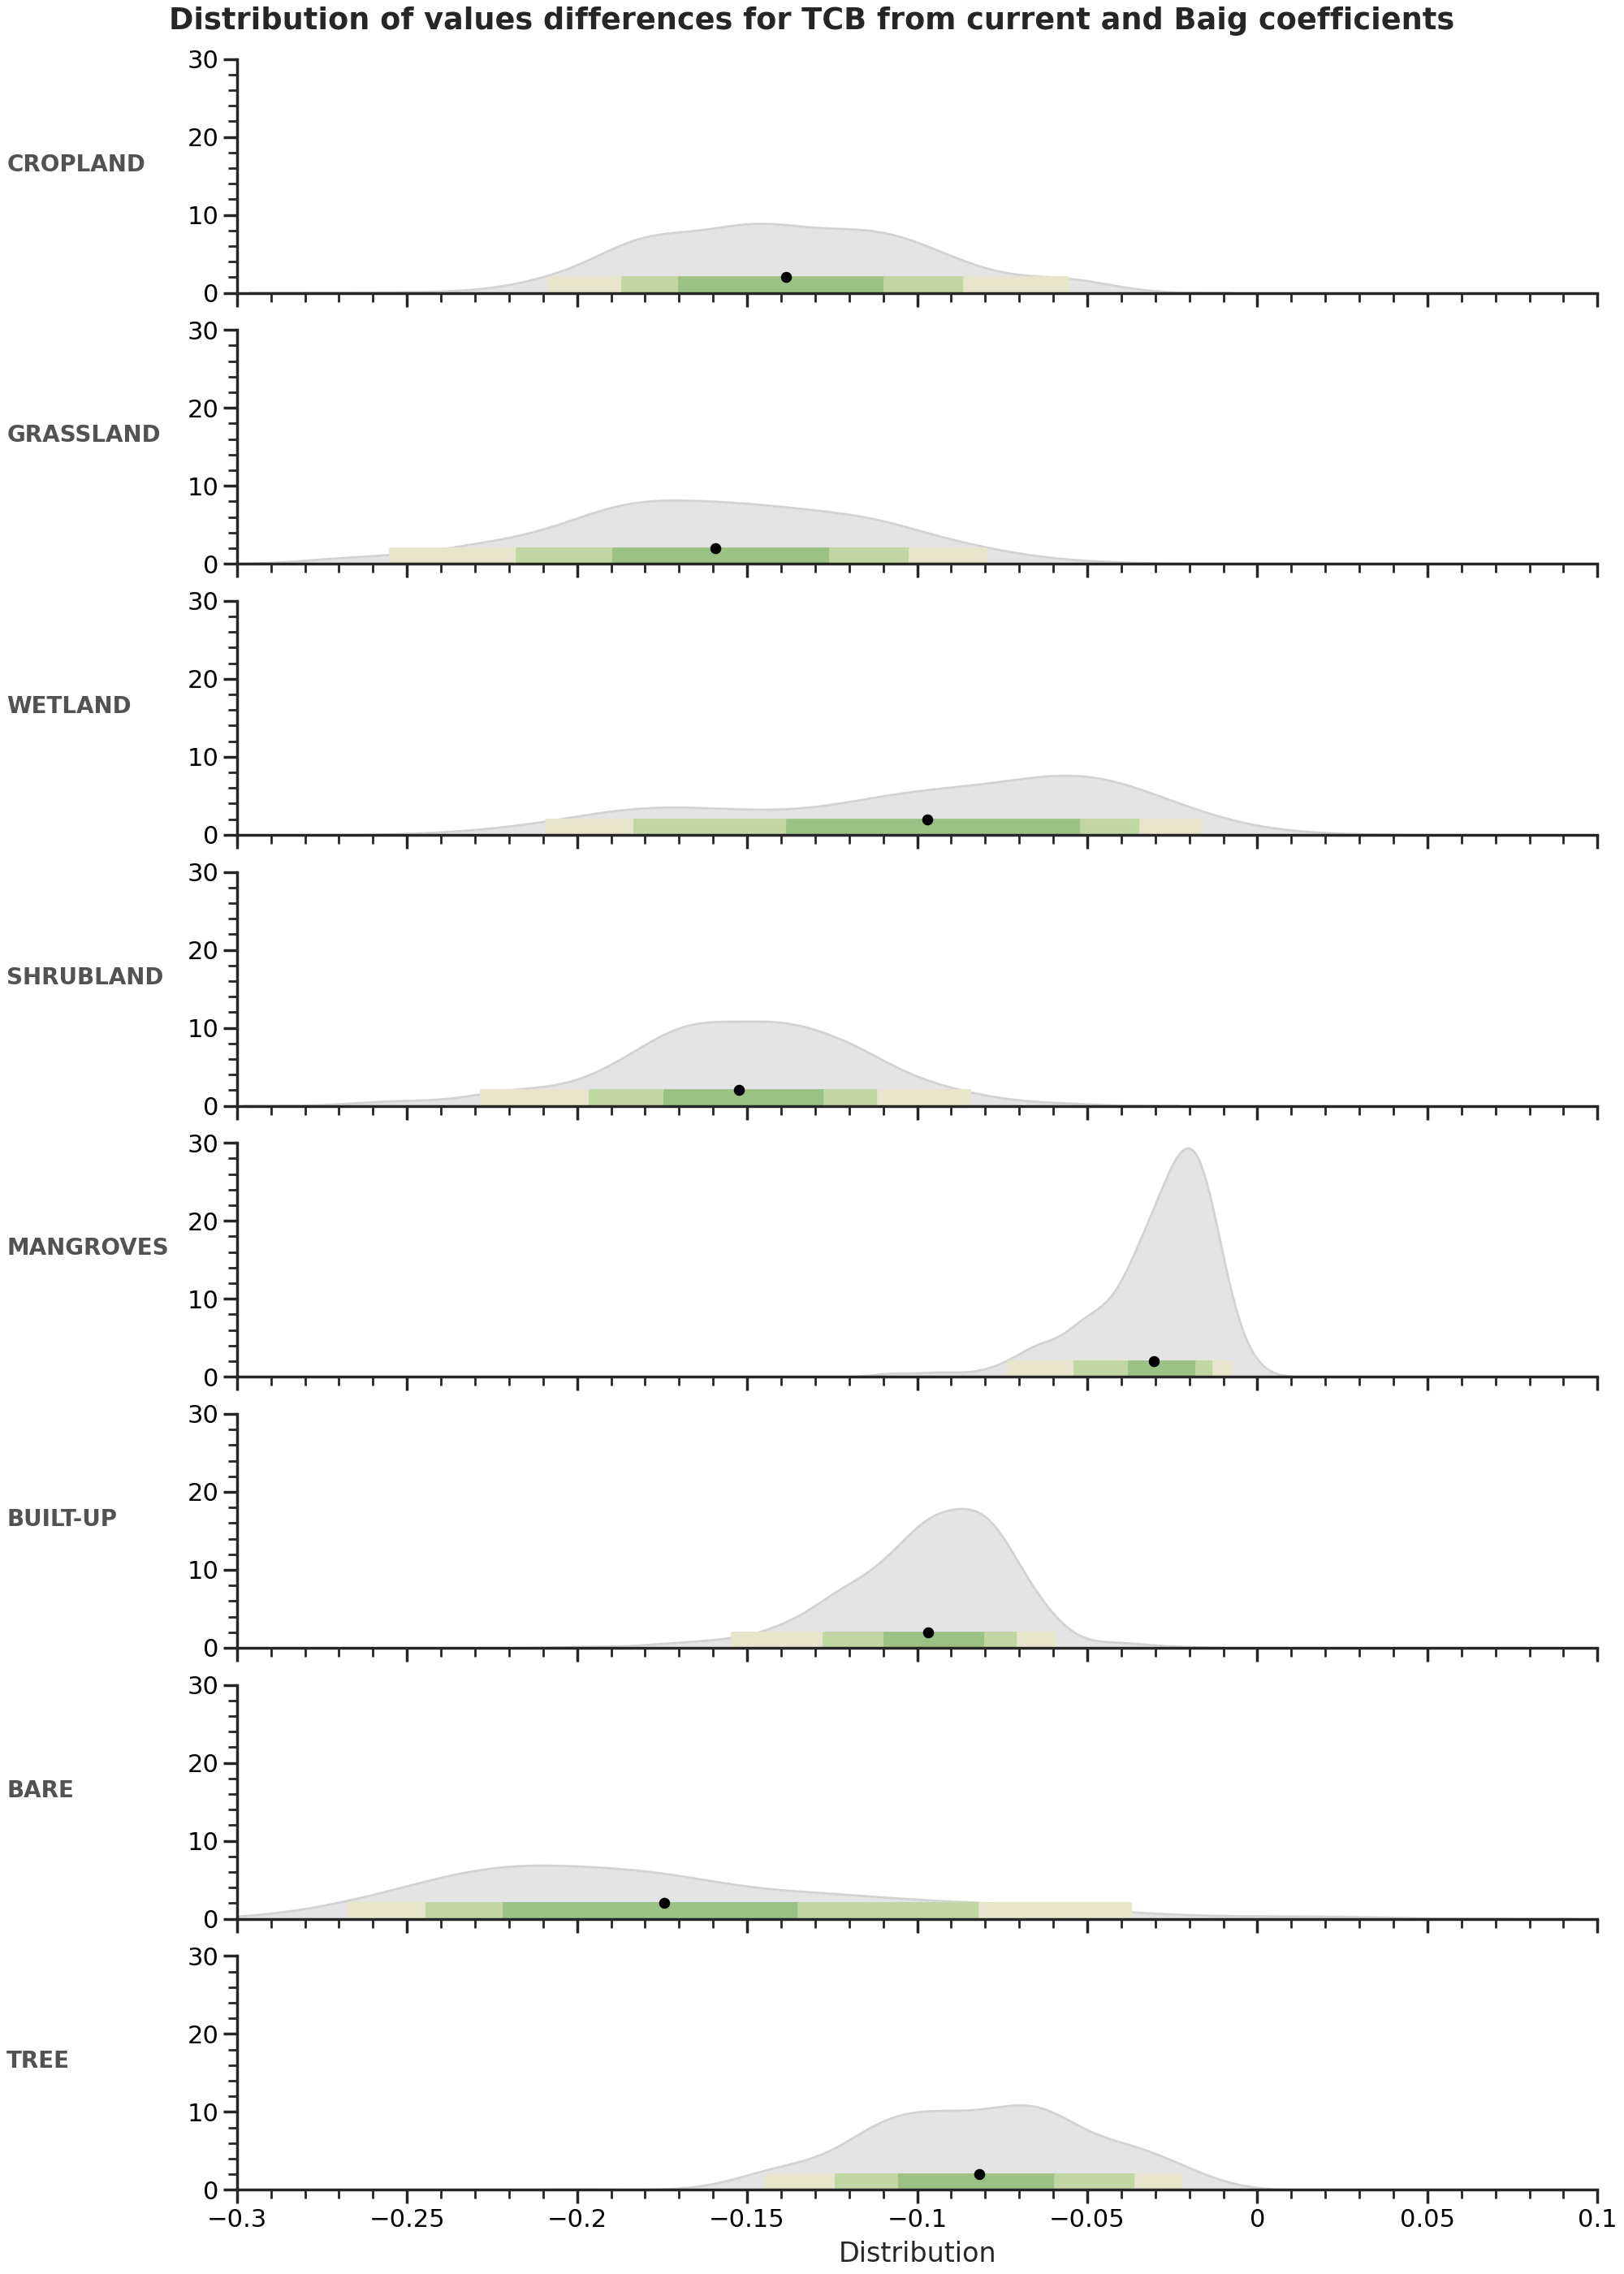

In [33]:
fig, axs = plt.subplots(nrows = len(classes), ncols=1, figsize=(10,14), layout='constrained', sharex=True)
axs = axs.flatten()


for i, cls in enumerate(classes):
    subset = combined_no_water_df[combined_no_water_df['classname'] == cls]

    sns.kdeplot(
        subset['diff_TCB_ls8'],
        shade=True,
        bw_adjust = bandwidth,
        ax = axs[i],
        color='grey',
        edgecolor='lightgrey',
    )


    # quantiles
    quantiles = np.percentile(subset['diff_TCB_ls8'], [2.5, 10, 25, 75, 90, 97.5])
    quantiles = list(quantiles)

    # fill space between each pair of quantiles
    for j in range(len(quantiles) - 1):
        axs[i].fill_between(
            [quantiles[j],
            quantiles[j + 1]],
            0,
            2,
            color=colors[j]
        )

    #add mean value as reference
    mean = subset['diff_TCB_ls8'].mean()
    axs[i].scatter([mean], [2], color='black', s=15)


    #title and labels
    axs[i].set_xlim(-0.3, 0.1)
    axs[i].set_ylim(0,30)
    axs[i].set_ylabel(cls.upper(), 
                      fontdict={'fontsize': 10, 'fontweight': 'bold', 'color': darkgrey}, 
                      rotation=0,
                     labelpad=80,
                     ha='left')
    axs[i].set_xlabel('Distribution')




fig.suptitle(f'Distribution of values differences for TCB from current and Baig coefficients')
fig.savefig("distributions_TCB_current_baig_by_esa_worldcover.png", dpi=100, bbox_inches='tight')



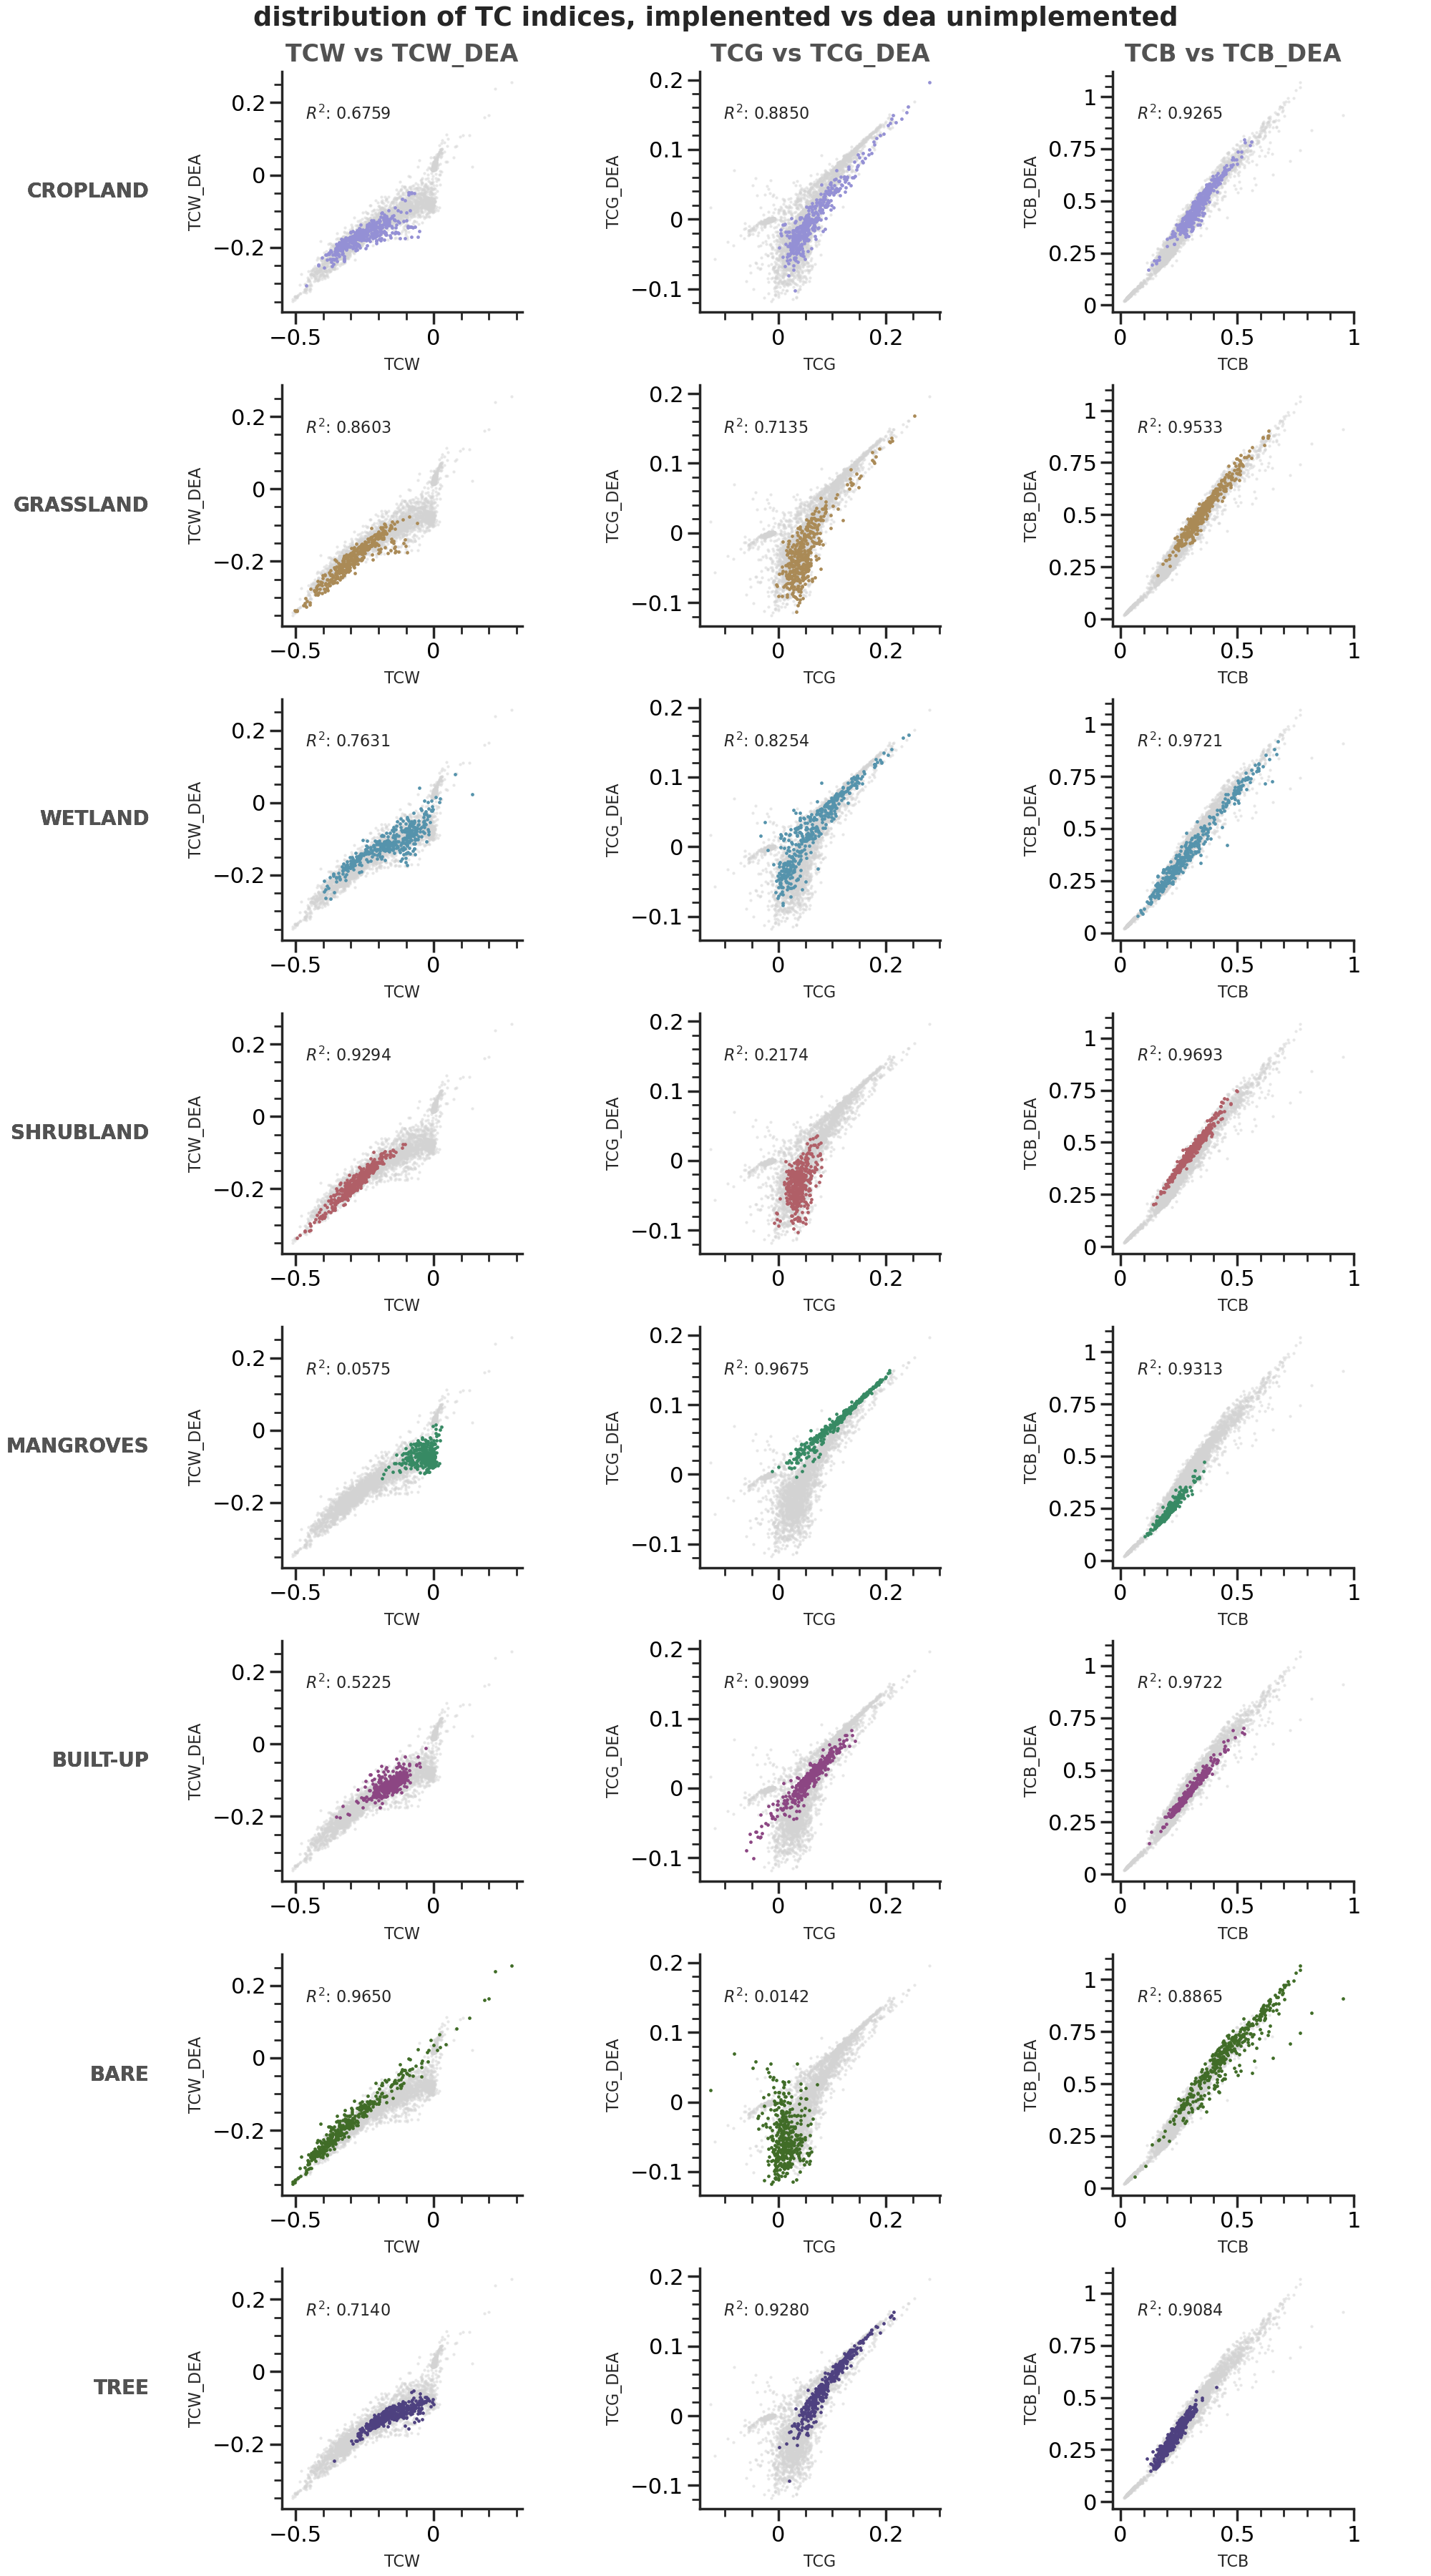

In [23]:
# for TWC, scatterplot of the 2 coefficients, with all points in light grey and the class in a bright colour
variable_pairs = [("TCW", "TCW_DEA"), ("TCG", "TCG_DEA"), ("TCB", "TCB_DEA")]

pal = sns.cubehelix_palette(8, rot=-10, light=.6, hue=1, dark=0.3)

fig, axs = plt.subplots(nrows= len(classes), ncols=3, figsize=(10,18), layout='constrained')

for i, (var1, var2) in enumerate(variable_pairs):
    column_name = var1

    data1 = combined_df[var1]
    data2 = combined_df[var2]

    
    # Set column title at the top row
    axs[0, i].set_title(f"{var1} vs {var2}", fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': darkgrey})


    for row, cls in enumerate(classes):
        ax = axs[row,i]
        color = pal[row]

        class_data = combined_df[combined_df['classname'] == cls]
        x = class_data[var1].values.reshape(-1,1)
        y = class_data[var2].values

        ax.scatter(data1, data2, color='lightgrey', marker='o', s=0.3, alpha=0.5)
        ax.scatter(x, y, color=color, marker='o', s=0.5)
        ax.set_box_aspect(1)


        if len(x) >1:
            model = LinearRegression()
            model.fit(x, y)
            r2 = model.score(x, y)
            ax.text(0.1, 0.8, 
                    f'$R^2$: {r2:.4f}', 
                    fontsize=8,
                    transform=ax.transAxes)

    
        # Add axis labels
        ax.set_xlabel(var1, fontsize=8)
        ax.set_ylabel(var2, fontsize=8)

            

    # Add class labels on the far left of each row
    for row, (cls, ax_row) in enumerate(zip(classes, axs)):
        ax_row[0].annotate(cls.upper(), 
                           xy = (0, 0.5),
                           xytext=(-0.55, 0.5),
                           xycoords='axes fraction',
                           textcoords='axes fraction',
                           fontsize=10, fontweight='bold', color=darkgrey,
                           ha='right', va='center',
                           annotation_clip=False)

        

fig.suptitle('distribution of TC indices, implenented vs dea unimplemented')
fig.savefig("scatter_plots_esa_worldcover_tc_implemented_vs_dea.png", dpi=100, bbox_inches='tight')


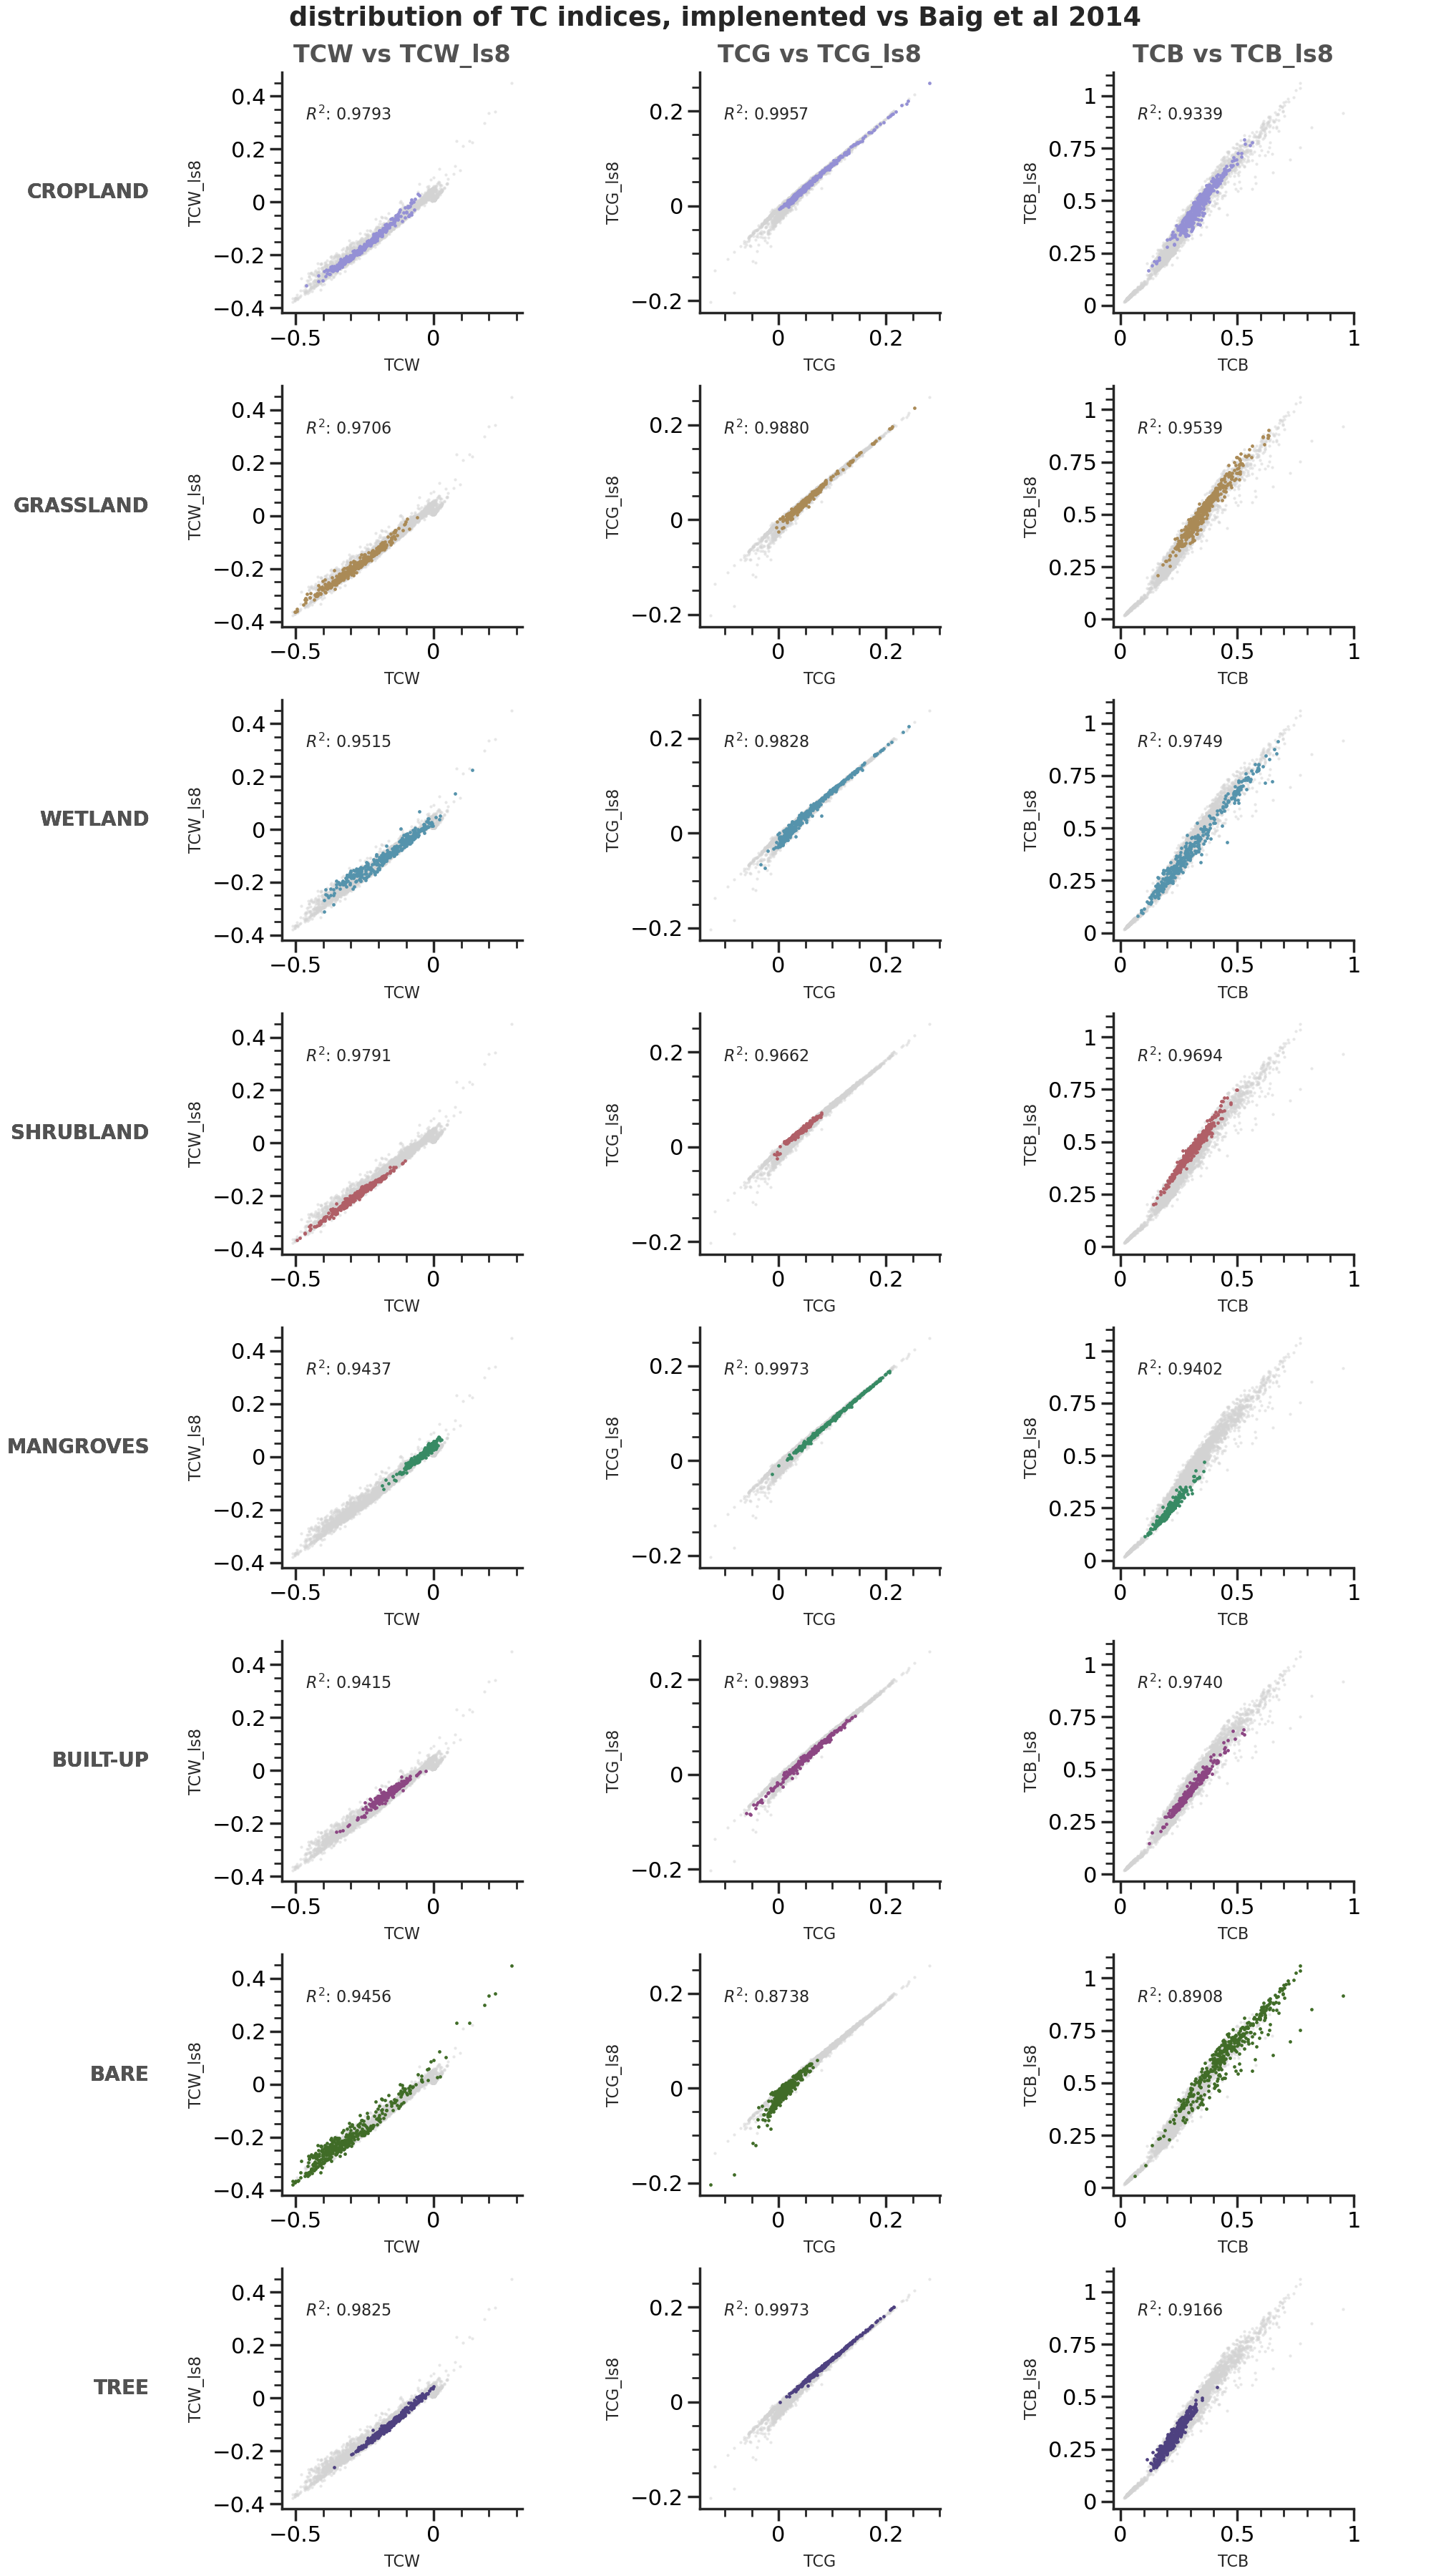

In [24]:
# for TWC, scatterplot of the 2 coefficients, with all points in light grey and the class in a bright colour
variable_pairs = [("TCW", "TCW_ls8"), ("TCG", "TCG_ls8"), ("TCB", "TCB_ls8")]

pal = sns.cubehelix_palette(8, rot=-10, light=.6, hue=1, dark=0.3)

fig, axs = plt.subplots(nrows= len(classes), ncols=3, figsize=(10,18), layout='constrained')

for i, (var1, var2) in enumerate(variable_pairs):
    column_name = var1

    data1 = combined_df[var1]
    data2 = combined_df[var2]

    
    # Set column title at the top row
    axs[0, i].set_title(f"{var1} vs {var2}", fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': darkgrey})


    for row, cls in enumerate(classes):
        ax = axs[row,i]
        color = pal[row]

        class_data = combined_df[combined_df['classname'] == cls]
        x = class_data[var1].values.reshape(-1,1)
        y = class_data[var2].values

        ax.scatter(data1, data2, color='lightgrey', marker='o', s=0.3, alpha=0.5)
        ax.scatter(x, y, color=color, marker='o', s=0.5)
        ax.set_box_aspect(1)


        if len(x) >1:
            model = LinearRegression()
            model.fit(x, y)
            r2 = model.score(x, y)
            ax.text(0.1, 0.8, 
                    f'$R^2$: {r2:.4f}', 
                    fontsize=8,
                    transform=ax.transAxes)

    
        # Add axis labels
        ax.set_xlabel(var1, fontsize=8)
        ax.set_ylabel(var2, fontsize=8)

            

    # Add class labels on the far left of each row
    for row, (cls, ax_row) in enumerate(zip(classes, axs)):
        ax_row[0].annotate(cls.upper(), 
                           xy = (0, 0.5),
                           xytext=(-0.55, 0.5),
                           xycoords='axes fraction',
                           textcoords='axes fraction',
                           fontsize=10, fontweight='bold', color=darkgrey,
                           ha='right', va='center',
                           annotation_clip=False)

        

fig.suptitle('distribution of TC indices, implenented vs Baig et al 2014')
fig.savefig("scatter_plots_esa_worldcover_tc_implemented_vs_baig.png", dpi=100, bbox_inches='tight')


In [36]:
rmse_df

,class,RMSE
0,TCW_ls8_bare,0.113000
1,TCW_ls8_built-up,0.076093
2,TCW_ls8_cropland,0.087272
3,TCW_ls8_grassland,0.095555
4,TCW_ls8_mangroves,0.049975
5,TCW_ls8_shrubland,0.082675
6,TCW_ls8_tree,0.059428
7,TCW_ls8_water,0.013849
8,TCW_ls8_wetland,0.079662
9,TCG_ls8_bare,0.020597
